# Notebook used to analyze, collect and reduce the multiwavelength data of EP240414a.

In [1]:
#Importing the packages used in the code
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import redback as rd
import astropy as ast
import pandas as pd
import warnings
import extinction as ex
warnings.filterwarnings('ignore')

/tmp/ipykernel_4058372/1610559072.py:3: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.5)
  import scipy as sc
/opt/anaconda3/envs/redback/lib/python3.11/site-packages/lalsimulation/lalsimulation.py:8: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal
17:51 bilby INFO    : Running bilby version: 2.7.1
17:51 redback INFO    : Running redback version: 1.15.3


Firstly, extracting all the optical, infrared and ultraviolet observational data from van Dalen et al 2025, Srivastav et al. 2025 and Sun et al. 2025; and the radio observational data from Bright et al. 2025 and Sun et al. 2025:

In [2]:
from astropy.table import Table, Column
from astropy import units as u
from astropy import constants as const
import astropy.io.ascii as ascii
import re

#For van Dalen et al. 2025 data:
pmetrytxt='EP240414a Data from different articles/Photometry Obtained with Various Ground-based Telescopes.txt'
pmetry = Table.read(pmetrytxt, format="ascii", comment="#")
spcopytxt='EP240414a Data from different articles/Spectroscopy Obtained with Various Ground-based Telescopes.txt'
spcopy = Table.read(spcopytxt, format="ascii", comment="#")
publicphototxt='EP240414a Data from different articles/Overview of the Publicly Available Photometry for EP240414a Obtained with Various Ground-based Telescopes.txt'
publicphoto = Table.read(publicphototxt, format="ascii", comment="#")

#For Srivastav et al. 2025 data:
Srivastxt='EP240414a Data from different articles/Srivastav optical.txt'
Srivas = Table.read(Srivastxt, format="ascii", comment="#")

#Radio Data from Bright et al. 2025 paper:
#The radio data is provided in a different format than the optical data, so we extract the data 
#'manually' distinguishing between detections and upper limits:
radio = ascii.read(
    'EP240414a Data from different articles/RadioDataBright.txt',
    delimiter='\t',
    comment='Note',
    guess=False,
    header_start=2,
    data_start=4
)

#Codes to go element by element in the .txt file extracting the radio data and separating it into
#detections and upper limits:
flux_strings = radio['Flux Density']
flux_values = []
flux_errors = []
flux_limits = []

for f in flux_strings:
    f = f.strip()
    if f.startswith('<'):
        flux_values.append(float(f[1:]))
        flux_errors.append(None)
        flux_limits.append(True)
    elif '+or-' in f:
        val, err = f.split('+or-')
        flux_values.append(float(val.strip()))
        flux_errors.append(float(err.strip()))
        flux_limits.append(False)
    else:
        flux_values.append(float(f))
        flux_errors.append(None)
        flux_limits.append(False)

# Add new columns
radio['Flux_Value'] = Column(flux_values)
radio['Flux_Error'] = Column(flux_errors)
radio['Upper_Limit'] = Column(flux_limits)


#Now, implementing the redshift from the source provided by Sun et al. 2025:
z=0.401
ez=0.003


#Introducing the optical data from Sun et al. 2025 'manually' since it was not provided
# a machine readable version of this set of data:
timeSunObserver=np.array([0.521, 1.196, 1.501, 1.519, 1.534, 3.632, 3.645, 3.656, 
                          3.662, 3.665, 3.671, 3.674, 4.4, 4.42, 4.668, 4.699, 5.52,
                          5.56, 5.569, 6.457, 15.258, 15.26, 15.322, 15.345, 15.35, 17.44, 17.92,
                          18.582, 19.553, 29.3, 29.3, 30.5, 43.65, 43.67, 43.69, 43.72, 49.94,
                          49.94, 49.96, 49.97])
MAGSUN=np.array([21.88, 20.50, 22.77, 22.32, 22.40, 20.62, 20.30, 21.26, 20.98, 20.96, 20.72, 20.65, 20.80, 20.37,
                 20.64, 20.62, 20.79, 21.16, 21.20, 21.0, 21.4, 20.6, 20.70, 19.70, 18.90, 22.1,
                 21.05, 22.24, 22.43, 22.50, 21.60, 22.40, 21.90, 22.65, 22.30, 23.14, 25.98, 24.19, 
                 23.54, 25.70])
MAGSUN_E=np.array([0.07, 0, 0.21, 0.19, 0.15, 0.1, 0.25, 0.24, 0.23, 0.16, 0.19, 0.14, 0.3, 0.26,
                   0.14, 0.08, 0.03, 0.16, 0, 0, 0, 0, 0, 0, 0, 0, 0.15, 0.11, 0.14, 0, 0, 0, 0, 0, 0, 0.19, 
                   0.21, 0.12, 0.16, 0.29])
FilterSUN=['r', 'R-UB', 'g', 'i', 'r', 'r', 'z', 'B', 'V', 'g', 'r', 'i', 'r', 'i', 'i', 'z', 'r', 'i',
        'z-UB', 'z-UB', 'i-UB', 'z-UB', 'g-UB', 'i-UB', 'z-UB', 'i-UB', 'J', 'i', 'z', 'R-UB', 'I-UB', 
        'i-UB', 'r-UB', 'g-UB', 'r-UB', 'i', 'g', 'R', 'I', 'V']

# Note that I will only take the magnitudes in the AB-system, this is: griz bands,
# the rest are in Vega magnitude system and since there is so few data in this magnitude system, 
# I have decided not to take them into account because we already have a lot of data in these frequency 
# bands and from a wide range of time periods.

## In this cell, I create the function that I use to propagate the errors through the computation. That is, I code a function that generates random realizations following an asymetric Gaussian distribution to work with the data as distributions and to facilitate the calculation of error propagation.

In [3]:
# I define a function to create the distributions of parameters with asymmetric 
#uncertainties to afterwards work in computations with Monte-Carlo techniques (with a number of 
# points equal to 'size').
def sample_split_normal(mu, sigma_left, sigma_right, size):
    #Sigma_left and _right are the left and right uncertainties of the value 'mu', respectively.
    sigma_left = float(sigma_left)
    sigma_right = float(sigma_right)
    #First, to check if the value has uncertainties.
    if sigma_left <= 0 and sigma_right <= 0:
        return np.full(size, mu)
    #Or if they are symmetric (one of the sigmas is zero or smaller).
    #If the uncertainties are symmetric, the distribution of the value is just an usual Gaussian
    if sigma_left <= 0:
        return np.random.normal(mu, sigma_right, size)
    if sigma_right <= 0:
        return np.random.normal(mu, sigma_left, size)
    #If the uncertainties are not symmetric and not zero:
    # Probability of the value to be at the left of the distribution:
    p_left = sigma_left / (sigma_left + sigma_right)
    #Now, creating an independent uniform distribution of points between 0 and 1 to compare it with p,
    #and separate the elements from the distribution between left and right of mu
    u = np.random.rand(size)
    #For a normal distribution around 0, but with absolute values to account for the weight of the points 
    #at each side of mu. That is, our distribution will be Gaussian but with different standard deviation 
    # at the right and left, so to separate the points belonging to each side of the mean, 
    # we need this absolute valued gaussian (with half-normal gaussian).
    absz = np.abs(np.random.randn(size))
    draws = np.empty(size)
    #Separating the points from the left and from the right with the probability of being at the left or right
    left_idx = u < p_left
    right_idx =~ left_idx
    draws[left_idx] = mu - absz[left_idx] * sigma_left
    draws[right_idx] = mu + absz[right_idx] * sigma_right
    return draws


#This simple function is implemented to extract the median, 84th and 16th persentiles from
# the distributions to be able to present the results:
def pct(arr, p):
        return np.percentile(arr, p)

## Now, I divide the extracted $\textbf{optical}$ data into different arrays based on the filters used to measure them and the times at which the observations were taken to be able to correct the data for extinction in each band in an easier way:

In [4]:
#Defining the empty arrays for the data:
rmag=np.array([])
rmage=np.array([])
tor=np.array([])
imag=np.array([])
image=np.array([])
toi=np.array([])
zmag=np.array([])
zmage=np.array([])
toz=np.array([])
gmag=np.array([])
gmage=np.array([])
tog=np.array([])

#Array to keep track of the articles from which the data was extracted:
sourceg=[]
sourcez=[]
sourcer=[]
sourcei=[]
#To account for the upper limits in a separate way.
rmagub=np.array([])
tormagub=np.array([])
imagub=np.array([])
toimagub=np.array([])
zmagub=np.array([])
tozmagub=np.array([])
gmagub=np.array([])
togmagub=np.array([])

sourcegUB=[]
sourcerUB=[]
sourceiUB=[]
sourcezUB=[]

#For the optical data from Sun et al. 2025:
for j in range(len(timeSunObserver)):
    if FilterSUN[j]=='r':
        rmag = np.append(rmag,MAGSUN[j])
        sourcer.append('Sun et al. 2025')
        rmage = np.append(rmage,MAGSUN_E[j])
        tor = np.append(tor,timeSunObserver[j])
    if FilterSUN[j]=='i':
        imag = np.append(imag,MAGSUN[j])
        sourcei.append('Sun et al. 2025')
        image = np.append(image,MAGSUN_E[j])
        toi = np.append(toi,timeSunObserver[j])
    if FilterSUN[j]=='g':
        gmag = np.append(gmag,MAGSUN[j])
        sourceg.append('Sun et al. 2025')
        gmage = np.append(gmage,MAGSUN_E[j])
        tog = np.append(tog,timeSunObserver[j])
    if FilterSUN[j]=='z':
        zmag = np.append(zmag,MAGSUN[j])
        sourcez.append('Sun et al. 2025')
        zmage = np.append(zmage,MAGSUN_E[j])
        toz = np.append(toz,timeSunObserver[j])    
    if FilterSUN[j]=='r-UB':
        rmagub = np.append(rmagub,MAGSUN[j])
        sourcerUB.append('Sun et al. 2025')
        tormagub = np.append(tormagub,timeSunObserver[j])
    if FilterSUN[j]=='i-UB':
        imagub = np.append(imagub,MAGSUN[j])
        sourceiUB.append('Sun et al. 2025')
        toimagub = np.append(toimagub,timeSunObserver[j])
    if FilterSUN[j]=='g-UB':
        gmagub = np.append(gmagub,MAGSUN[j])
        sourcegUB.append('Sun et al. 2025')
        togmagub = np.append(togmagub,timeSunObserver[j])
    if FilterSUN[j]=='z-UB':
        zmagub = np.append(zmagub,MAGSUN[j])
        sourcezUB.append('Sun et al. 2025')
        tozmagub = np.append(tozmagub,timeSunObserver[j])


#For the optical data from van Dalen et al. 2025:
for j in range(len(pmetry['ABMag'].data)):
    if pmetry['Filter'].data[j]=='r':
        if np.ma.is_masked(pmetry['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter r')
        else:
            rmag = np.append(rmag,pmetry['ABMag'].value[j])
            sourcer.append('van Dalen et al. 2025')
            rmage = np.append(rmage,pmetry['e_ABMag'].value[j])
            tor = np.append(tor,pmetry['SinceTriggerObserved'].value[j])
    if pmetry['Filter'].data[j]=='i':
        if np.ma.is_masked(pmetry['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter i')
        else:
            imag = np.append(imag,pmetry['ABMag'].value[j])
            sourcei.append('van Dalen et al. 2025')
            image = np.append(image,pmetry['e_ABMag'].value[j])
            toi = np.append(toi,pmetry['SinceTriggerObserved'].value[j])
    if pmetry['Filter'].data[j]=='z':
        if np.ma.is_masked(pmetry['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter z')
        else:
            zmag = np.append(zmag,pmetry['ABMag'].value[j])
            sourcez.append('van Dalen et al. 2025')
            zmage = np.append(zmage,pmetry['e_ABMag'].value[j])
            toz = np.append(toz,pmetry['SinceTriggerObserved'].value[j])
    if pmetry['Filter'].data[j]=='g':
        if np.ma.is_masked(pmetry['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter g')
        else:
            gmag = np.append(gmag,pmetry['ABMag'].value[j])
            sourceg.append('van Dalen et al. 2025')
            gmage = np.append(gmage,pmetry['e_ABMag'].value[j])
            tog = np.append(tog,pmetry['SinceTriggerObserved'].value[j])
            
#Creating the upper limit arrays from the information provided by the loops:
gmagub=np.append(gmagub, pmetry['ABMag'].value[2])
sourcegUB.append('van Dalen et al. 2025')
togmagub=np.append(togmagub, pmetry['SinceTriggerObserved'].value[2])
rmagub=np.append(rmagub, pmetry['ABMag'].value[6])
sourcerUB.append('van Dalen et al. 2025')
tormagub=np.append(tormagub, pmetry['SinceTriggerObserved'].value[6])
imagub=np.append(imagub, np.array([pmetry['ABMag'].value[7], pmetry['ABMag'].value[43]]))
sourceiUB.append('van Dalen et al. 2025')
sourceiUB.append('van Dalen et al. 2025')
toimagub=np.append(toimagub, np.array([pmetry['SinceTriggerObserved'].value[7], pmetry['SinceTriggerObserved'].value[43]]))

At the position  2 there is an upper bound for the filter g
At the position  6 there is an upper bound for the filter r
At the position  7 there is an upper bound for the filter i
At the position  43 there is an upper bound for the filter i


In [5]:
#For the other table of optical data provided by van Dalen et al. 2025:
for j in range(len(publicphoto['ABMag'].data)):
    if publicphoto['Filter'].data[j]=='r':
        if np.ma.is_masked(publicphoto['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter r')
        else:
            rmag = np.append(rmag,publicphoto['ABMag'].value[j])
            sourcer.append('van Dalen et al. 2025')
            rmage = np.append(rmage,publicphoto['e_ABMag'].value[j])
            tor = np.append(tor,publicphoto['SinceTriggerObserved'].value[j])
    if publicphoto['Filter'].data[j]=='i':
        if np.ma.is_masked(publicphoto['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter i')
        else:
            imag = np.append(imag,publicphoto['ABMag'].value[j])
            sourcei.append('van Dalen et al. 2025')
            image = np.append(image,publicphoto['e_ABMag'].value[j])
            toi = np.append(toi,publicphoto['SinceTriggerObserved'].value[j])
    if publicphoto['Filter'].data[j]=='g':
        if np.ma.is_masked(publicphoto['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter g')
        else:
            gmag = np.append(gmag,publicphoto['ABMag'].value[j])
            sourceg.append('van Dalen et al. 2025')
            gmage = np.append(gmage,publicphoto['e_ABMag'].value[j])
            tog = np.append(tog,publicphoto['SinceTriggerRest'].value[j])

At the position  6 there is an upper bound for the filter g
At the position  7 there is an upper bound for the filter r
At the position  8 there is an upper bound for the filter i


In [6]:
#For the Srivastav et al. 2025 optical data:
for j in range(len(Srivas['mag'].data)):
    if Srivas['Filter'].data[j]=='r':
        if np.ma.is_masked(Srivas['e_mag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter r')
        else:
            rmag = np.append(rmag,Srivas['mag'].value[j])
            sourcer.append('Srivastav et al. 2025')
            rmage = np.append(rmage,Srivas['e_mag'].value[j])
            tor = np.append(tor,Srivas['dt'].value[j])
    if Srivas['Filter'].data[j]=='i':
        if np.ma.is_masked(Srivas['e_mag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter i')
        else:
            imag = np.append(imag,Srivas['mag'].value[j])
            sourcei.append('Srivastav et al. 2025')
            image = np.append(image,Srivas['e_mag'].value[j])
            toi = np.append(toi,Srivas['dt'].value[j])
    if Srivas['Filter'].data[j]=='g':
        if np.ma.is_masked(Srivas['e_mag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter g')
        else:
            gmag = np.append(gmag,Srivas['mag'].value[j])
            sourceg.append('Srivastav et al. 2025')
            gmage = np.append(gmage,Srivas['e_mag'].value[j])
            tog = np.append(tog,Srivas['dt'].value[j])
    if Srivas['Filter'].data[j]=='z':
        if np.ma.is_masked(Srivas['e_mag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter z')
        else:
            zmag = np.append(zmag,Srivas['mag'].value[j])
            sourcez.append('Srivastav et al. 2025')
            zmage = np.append(zmage,Srivas['e_mag'].value[j])
            toz = np.append(toz,Srivas['dt'].value[j])

#Implementing the upper limit arrays from the information provided by the loops:
gmagub=np.append(gmagub,[publicphoto['ABMag'].value[6], Srivas['mag'].value[21]])
sourcegUB.append('van Dalen et al. 2025')
sourcegUB.append('Srivastav et al. 2025')
togmagub=np.append(togmagub,[publicphoto['SinceTriggerObserved'].value[6], Srivas['dt'].value[21]])*u.d
rmagub=np.append(rmagub,[publicphoto['ABMag'].value[7], Srivas['mag'].value[5], Srivas['mag'].value[27]])
sourcerUB.append('van Dalen et al. 2025')
sourcerUB.append('Srivastav et al. 2025')
sourcerUB.append('Srivastav et al. 2025')
tormagub=np.append(tormagub,[publicphoto['SinceTriggerObserved'].value[7], Srivas['dt'].value[5], Srivas['dt'].value[27]])*u.d
imagub=np.append(imagub,[publicphoto['ABMag'].value[8], Srivas['mag'].value[41]])
sourceiUB.append('van Dalen et al. 2025')
sourceiUB.append('Srivastav et al. 2025')
toimagub=np.append(toimagub,[publicphoto['SinceTriggerObserved'].value[8], Srivas['dt'].value[41]])*u.d

#Changing units in the time arrays from seconds to days for plotting purposes:
toi=toi*u.d
tor=tor*u.d
tog=tog*u.d
toz=toz*u.d
tozmagub=tozmagub*u.d

At the position  5 there is an upper bound for the filter r
At the position  21 there is an upper bound for the filter g
At the position  27 there is an upper bound for the filter r
At the position  41 there is an upper bound for the filter i


As a consistency check, I plotted the data in this cell to visually compare it with the figures in the articles from which the data was extracted, although it is still not extinction corrected. So, I am mainly doing this to check the approximate shape of the light curve obtained.

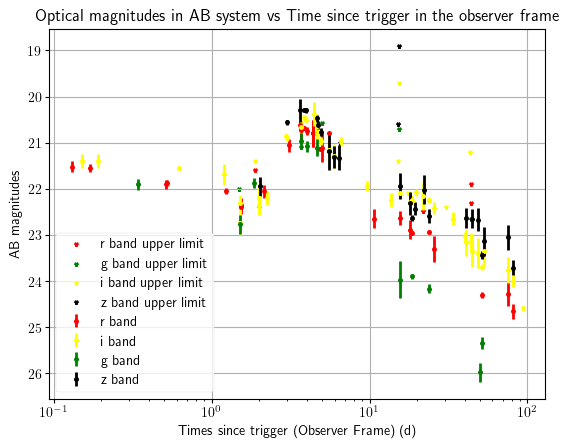

In [7]:
plt.figure()
plt.errorbar(tor, rmag, yerr=rmage, fmt='o', capsize=5, elinewidth=2, color='red', label='r band')
plt.errorbar(toi, imag, yerr=image, fmt='o', capsize=5, elinewidth=2, color='yellow', label='i band')
plt.errorbar(tog, gmag, yerr=gmage, fmt='o', capsize=5, elinewidth=2, color='green', label='g band')
plt.errorbar(toz, zmag, yerr=zmage, fmt='o', capsize=5, elinewidth=2, color='black', label='z band')
plt.scatter(tormagub, rmagub, color='red', marker='1', linewidth=2, label='r band upper limit')
plt.scatter(togmagub, gmagub, color='green',marker='1', linewidth=2, label='g band upper limit')
plt.scatter(toimagub, imagub, color='yellow', marker='1', linewidth=2, label='i band upper limit')
plt.scatter(tozmagub, zmagub, color='black', marker='1', linewidth=2, label='z band upper limit')
plt.gca().invert_yaxis()
plt.title('Optical magnitudes in AB system vs Time since trigger in the observer frame')
plt.xlabel('Times since trigger (Observer Frame) (d)')
plt.ylabel('AB magnitudes')
plt.xscale('log')
plt.legend()
plt.grid()
plt.show()

Next, I will correct the optical data obtained for galactic extinction:

Relative systematic uncertainty in the magnitude data points (%) taken into account in van Dalen et al. data points is: [0.         0.         0.         1.37933709 1.42929871 1.25783394
 1.26157802 1.24740895 1.18903453 0.         0.         0.
 0.         0.         0.         0.         0.         1.37504765
 1.34735867 1.45649307 1.4253408  1.32947948 1.33043079 1.31134559
 1.31251566 1.29211733 1.23830394 1.22069864 1.39947282 1.44839113
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         1.39589261 1.32253346 1.47193474
 1.44694032 1.42169905 1.43463426 1.3710605  1.35249721 1.36173184
 1.35129047 1.36236929 1.35189183 1.34222511 1.32805145 1.30595034
 1.26902414 1.25257393 1.40561903 1.35502467 1.439408   0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         1

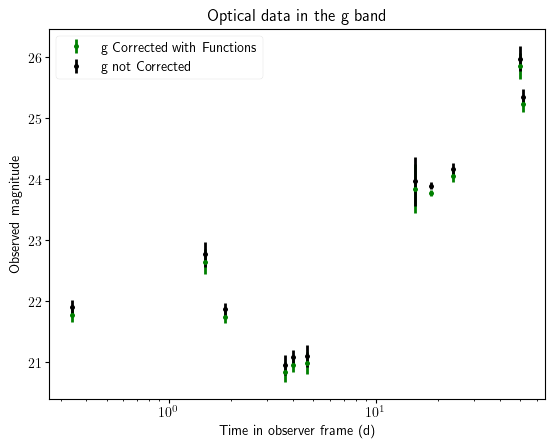

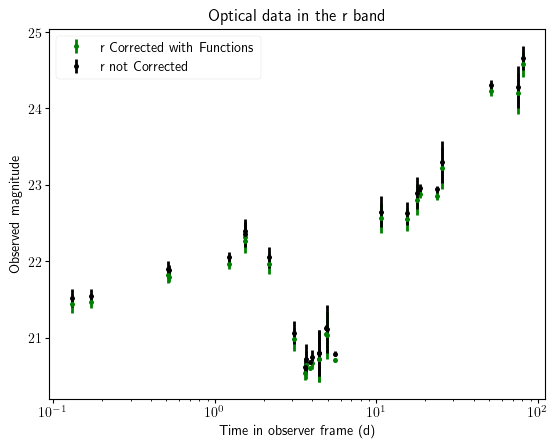

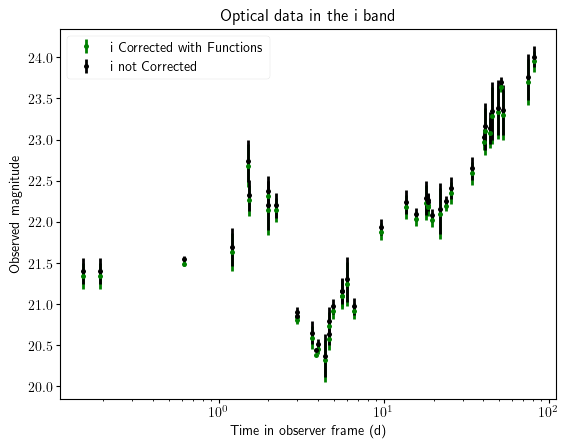

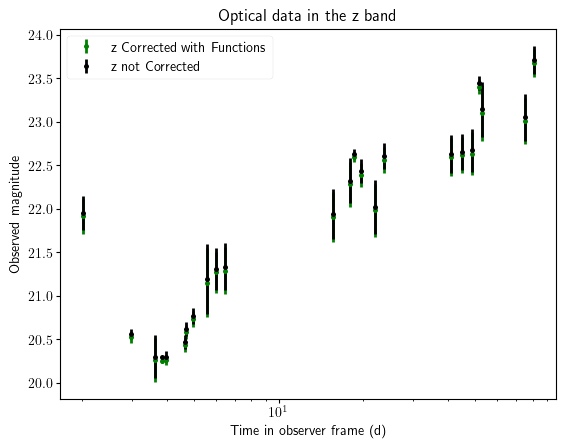

In [8]:
#Defining the function to correct the optical data for the galactic extinction effect:
def OpticGalCorrec(magn, RvOwnGal, EOwnGal, RvHostGal, EHostGal):
    return magn - RvOwnGal*EOwnGal - RvHostGal*EHostGal

#For the line-of-sight Milky Way extinction:
EMW=0.031563 #Milky Way color excess calculated from a separate notebook and
            #using the astronomical coordinates of the event 
RvMW=3.1 #Milky Way reddening parameter obtained from E.F. Schlafly and D.P. Finkbeiner 2011
AvCalz=RvMW*EMW

#In addition, assuming for the computations effective wavelengths for the optical filters 
# used equal to the SDSS filtes ones:
LambEffSDSS=np.array([4686, 6165, 7481, 8931], dtype='float64') #In Armstrongs
#Order of the filters: g r i z

#For the MC techniques to propagate the errors (number of samples):
LengthOFMC=20000

#Note that, for the host galaxy extinction effect, I am not correcting due to the big physical offset 
# of the event with respect to the host galaxy.

#Finally, using the D. Calzetti et al. 2000 dust model for correcting for galactic extinction:

#Milky Way extinction for each optical filter:
CalcDist=ex.calzetti00(LambEffSDSS, AvCalz, RvMW)

#Propagating the errors using the MC technique:
gMagsDist=[]
rMagsDist=[]
iMagsDist=[]
zMagsDist=[]
for i in range(0,len(gmag)):
    gMagsDist.append(sample_split_normal(gmag[i],gmage[i],0,LengthOFMC))
for i in range(0,len(rmag)):
    rMagsDist.append(sample_split_normal(rmag[i],rmage[i],0,LengthOFMC))
for i in range(0,len(imag)):
    iMagsDist.append(sample_split_normal(imag[i],image[i],0,LengthOFMC))
for i in range(0,len(zmag)):
    zMagsDist.append(sample_split_normal(zmag[i],zmage[i],0,LengthOFMC))

#We obtain the following galactic extinction corrected optical magnitudes (in distributions):
for i in range(0,len(LambEffSDSS)):
    if i==0: #g filter:
        gMagExCdist= gMagsDist - CalcDist[i]
    if i==1: #r filter:
        rMagExCdist= rMagsDist - CalcDist[i]
    if i==2: #i filter:
        iMagExCdist= iMagsDist - CalcDist[i]
    if i==3: #z filter:
        zMagExCdist= zMagsDist - CalcDist[i]


# Upper limits in the optical data:
# These are points instead of distributions because they are upper limits.
for i in range(0,len(LambEffSDSS)):
    if i==0: #g filter:
        gmagub= gmagub - CalcDist[i]
    if i==1: #r filter:
        rmagub= rmagub - CalcDist[i]
    if i==2: #i filter:
        imagub= imagub - CalcDist[i]
    if i==3: #z filter:
        zmagub= zmagub - CalcDist[i]





#To have the corrected values with uncertainties:
gMagExC=np.zeros(len(gmag))
gMagExC_e=np.zeros(len(gmag))
gMagExC_E=np.zeros(len(gmag))
rMagExC=np.zeros(len(rmag))
rMagExC_e=np.zeros(len(rmag))
rMagExC_E=np.zeros(len(rmag))
iMagExC=np.zeros(len(imag))
iMagExC_e=np.zeros(len(imag))
iMagExC_E=np.zeros(len(imag))
zMagExC=np.zeros(len(zmag))
zMagExC_e=np.zeros(len(zmag))
zMagExC_E=np.zeros(len(zmag))


# To study what relative systematic uncertainty is accounted for with the 0.3 mag 
# assumed as systematic error in van Dalen et al. 2025 data:
F_relg=np.zeros(len(gmag))
F_relr=np.zeros(len(rmag))
F_reli=np.zeros(len(imag))
F_relz=np.zeros(len(zmag))

for i in range(0,len(gmag)):
    gMagExC[i]=pct(gMagExCdist[i],50)
    if sourceg[i]=='van Dalen et al. 2025': #van Dalen et al. 2025 data
        F_relg[i]=0.3/gMagExC[i]
        gMagExC_e[i]=gMagExC[i]-pct(gMagExCdist[i],16)
        gMagExC_E[i]=pct(gMagExCdist[i],84)-gMagExC[i]
    else: #Srivastav data and Sun, without the systematic error included:
        gMagExC_e[i]=gMagExC[i]-pct(gMagExCdist[i],16)
        gMagExC_E[i]=pct(gMagExCdist[i],84)-gMagExC[i]
for i in range(0,len(rmag)):
    rMagExC[i]=pct(rMagExCdist[i],50)
    if sourcer[i]=='van Dalen et al. 2025': #van Dalen et al. 2025 data
        F_relr[i]=0.3/rMagExC[i]
        rMagExC_e[i]=rMagExC[i]-pct(rMagExCdist[i],16)
        rMagExC_E[i]=pct(rMagExCdist[i],84)-rMagExC[i]
    else: #Srivastav data and Sun, without the systematic error included:
        rMagExC_e[i]=rMagExC[i]-pct(rMagExCdist[i],16)
        rMagExC_E[i]=pct(rMagExCdist[i],84)-rMagExC[i]
for i in range(0,len(imag)):
    iMagExC[i]=pct(iMagExCdist[i],50)
    if sourcei[i]=='van Dalen et al. 2025': #van Dalen et al. 2025 data
        F_reli[i]=0.3/iMagExC[i]
        iMagExC_e[i]=iMagExC[i]-pct(iMagExCdist[i],16)
        iMagExC_E[i]=pct(iMagExCdist[i],84)-iMagExC[i]
    else: #Srivastav data and Sun, without the systematic error included:
        iMagExC_e[i]=iMagExC[i]-pct(iMagExCdist[i],16)
        iMagExC_E[i]=pct(iMagExCdist[i],84)-iMagExC[i]
for i in range(0,len(zmag)):
    zMagExC[i]=pct(zMagExCdist[i],50)
    if sourcez[i]=='van Dalen et al. 2025': #van Dalen et al. 2025 data
        F_relz[i]=0.3/zMagExC[i]
        zMagExC_e[i]=zMagExC[i]-pct(zMagExCdist[i],16)
        zMagExC_E[i]=pct(zMagExCdist[i],84)-zMagExC[i]
    else: #Srivastav data and Sun, without the systematic error included:
        zMagExC_e[i]=zMagExC[i]-pct(zMagExCdist[i],16)
        zMagExC_E[i]=pct(zMagExCdist[i],84)-zMagExC[i]


F_rel=np.append(F_relg,F_relr)
F_rel=np.append(F_rel,F_reli)
F_rel=np.append(F_rel,F_relz)
print('Relative systematic uncertainty in the magnitude data points (%) taken into account in van Dalen et al. data points is:', F_rel*100)



#Plotting the extinction corrected results to compare with the figures presented in the articles:
#g band
plt.figure()
plt.errorbar(tog,gMagExC,yerr=np.vstack([gMagExC_e, gMagExC_E]), fmt='o', capsize=5, elinewidth=2, color='green', label='g Corrected with Functions')
plt.errorbar(tog,gmag,yerr=gmage, fmt='o', capsize=5, elinewidth=2, color='black', label='g not Corrected')
plt.title('Optical data in the g band')
plt.xlabel('Time in observer frame (d)')
plt.ylabel('Observed magnitude')
plt.xscale('log')
plt.legend()

#r band
plt.figure()
plt.errorbar(tor,rMagExC,yerr=np.vstack([rMagExC_e, rMagExC_E]), fmt='o', capsize=5, elinewidth=2, color='green', label='r Corrected with Functions')
plt.errorbar(tor,rmag,yerr=rmage,fmt='o', capsize=5, elinewidth=2, color='black', label='r not Corrected')
plt.title('Optical data in the r band')
plt.xlabel('Time in observer frame (d)')
plt.ylabel('Observed magnitude')
plt.xscale('log')
plt.legend()

#i band
plt.figure()
plt.errorbar(toi,iMagExC,yerr=np.vstack([iMagExC_e, iMagExC_E]), fmt='o', capsize=5, elinewidth=2, color='green', label='i Corrected with Functions')
plt.errorbar(toi,imag,yerr=image,fmt='o', capsize=5, elinewidth=2, color='black', label='i not Corrected')
plt.title('Optical data in the i band')
plt.xlabel('Time in observer frame (d)')
plt.ylabel('Observed magnitude')
plt.xscale('log')
plt.legend()

#z band
plt.figure()
plt.errorbar(toz,zMagExC,yerr=np.vstack([zMagExC_e, zMagExC_E]),fmt='o', capsize=5, elinewidth=2, color='green', label='z Corrected with Functions')
plt.errorbar(toz,zmag,yerr=zmage,fmt='o', capsize=5, elinewidth=2, color='black', label='z not Corrected')
plt.title('Optical data in the z band')
plt.xlabel('Time in observer frame (d)')
plt.ylabel('Observed magnitude')
plt.xscale('log')
plt.legend()

plt.show()

Systematic relative error in the flux introduced by van Dalen et al. 2025 in their data for the fitting process in %:
g band: [ 0.          0.          0.         27.98395818 27.98395818 27.98395818
 27.98395818 27.98395818 27.98395818  0.          0.        ]
r band [ 0.          0.          0.          0.          0.          0.
 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818
 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818
 27.98395818  0.          0.          0.          0.          0.
  0.          0.          0.        ]
i band: [ 0.          0.          0.          0.          0.          0.
  0.         27.98395818 27.98395818 27.98395818 27.98395818 27.98395818
 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818
 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818 27.98395818
 27.98395818 27.98395818 27.98395818  0.          0.          0.
  0.          0.          0.          0.          0.         

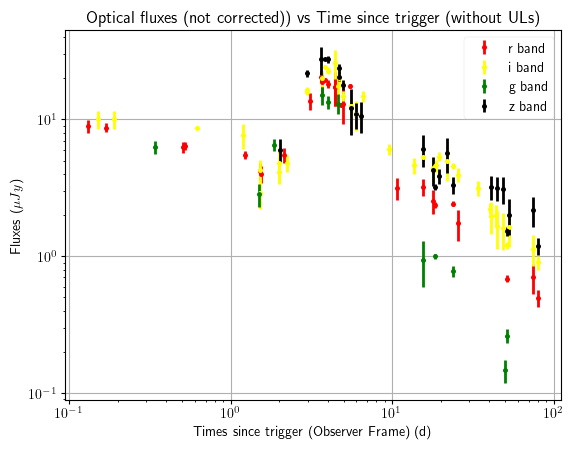

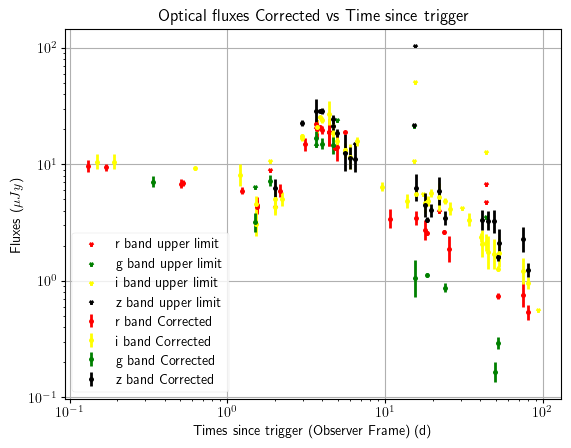

In [9]:
#Calculating the optical flux densities from the magnitudes in the AB system:
#Function for changing from magnitudes in AB system to Fluxes in erg/(s Hz cm^2) (Oke and Gunn 1983):
def fluxchangeAB(mab):
    return 10**(-0.4 * (mab + 48.60))

# Now, computing the systematic relative error in the fluxes that van Dalen et al. 2025 included in
# their analysis:
Fluxrelg=fluxchangeAB(gMagExC)
Fluxrelg_E=fluxchangeAB(gMagExC+gMagExC*F_relg)
Fluxrelg_e=fluxchangeAB(gMagExC-gMagExC*F_relg)
FluxrelgMean=((np.abs(Fluxrelg_E-Fluxrelg)+np.abs(Fluxrelg_e-Fluxrelg))/2)/Fluxrelg

Fluxrelr=fluxchangeAB(rMagExC)
Fluxrelr_E=fluxchangeAB(rMagExC+rMagExC*F_relr)
Fluxrelr_e=fluxchangeAB(rMagExC-rMagExC*F_relr)
FluxrelrMean=((np.abs(Fluxrelr_E-Fluxrelr)+np.abs(Fluxrelr_e-Fluxrelr))/2)/Fluxrelr

Fluxreli=fluxchangeAB(iMagExC)
Fluxreli_E=fluxchangeAB(iMagExC+iMagExC*F_reli)
Fluxreli_e=fluxchangeAB(iMagExC-iMagExC*F_reli)
FluxreliMean=((np.abs(Fluxreli_E-Fluxreli)+np.abs(Fluxreli_e-Fluxreli))/2)/Fluxreli

Fluxrelz=fluxchangeAB(zMagExC)
Fluxrelz_E=fluxchangeAB(zMagExC+zMagExC*F_relz)
Fluxrelz_e=fluxchangeAB(zMagExC-zMagExC*F_relz)
FluxrelzMean=((np.abs(Fluxrelz_E-Fluxrelz)+np.abs(Fluxrelz_e-Fluxrelz))/2)/Fluxrelz


print('Systematic relative error in the flux introduced by van Dalen et al. 2025 in their data for the fitting process in %:')
print('g band:', FluxrelgMean*100)
print('r band', FluxrelrMean*100)
print('i band:', FluxreliMean*100)
print('z band:', FluxrelzMean*100)


#In microJy, better units for these values (fluxes obtained without correcting for 
# galactic extinction for comparing purposes with the extinction corrected one):
fluxr = (fluxchangeAB(rmag)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxi = (fluxchangeAB(imag)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxg = (fluxchangeAB(gmag)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxz = (fluxchangeAB(zmag)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)

fluxrDist = fluxchangeAB(rMagExCdist)
fluxiDist = fluxchangeAB(iMagExCdist)
fluxgDist = fluxchangeAB(gMagExCdist)
fluxzDist = fluxchangeAB(zMagExCdist)

#For the uncertainty, calculating it analytically from the partial derivatives method.
# Note that this is the error for the non-corrected fluxes with the purpose of comparing them
# with the extinction corrected ones:
efluxr=0.4*np.log(10)*fluxr*rmage
efluxi=0.4*np.log(10)*fluxi*image
efluxg=0.4*np.log(10)*fluxg*gmage
efluxz=0.4*np.log(10)*fluxz*zmage



#For the extinction corrected flux densities, using MC techniques we obtain distributions:
fluxgMagCorr=np.zeros(len(gmag))
fluxgMagCorr_e=np.zeros(len(gmag))
fluxgMagCorr_E=np.zeros(len(gmag))
fluxrMagCorr=np.zeros(len(rmag))
fluxrMagCorr_e=np.zeros(len(rmag))
fluxrMagCorr_E=np.zeros(len(rmag))
fluxiMagCorr=np.zeros(len(imag))
fluxiMagCorr_e=np.zeros(len(imag))
fluxiMagCorr_E=np.zeros(len(imag))
fluxzMagCorr=np.zeros(len(zmag))
fluxzMagCorr_e=np.zeros(len(zmag))
fluxzMagCorr_E=np.zeros(len(zmag))

for i in range(0,len(gmag)):
    fluxgMagCorr[i]=pct(fluxgDist[i],50)
    fluxgMagCorr_e[i]=fluxgMagCorr[i]-pct(fluxgDist[i],16)
    fluxgMagCorr_E[i]=pct(fluxgDist[i],84)-fluxgMagCorr[i]
for i in range(0,len(rmag)):
    fluxrMagCorr[i]=pct(fluxrDist[i],50)
    fluxrMagCorr_e[i]=fluxrMagCorr[i]-pct(fluxrDist[i],16)
    fluxrMagCorr_E[i]=pct(fluxrDist[i],84)-fluxrMagCorr[i]
for i in range(0,len(imag)):
    fluxiMagCorr[i]=pct(fluxiDist[i],50)
    fluxiMagCorr_e[i]=fluxiMagCorr[i]-pct(fluxiDist[i],16)
    fluxiMagCorr_E[i]=pct(fluxiDist[i],84)-fluxiMagCorr[i]
for i in range(0,len(zmag)):
    fluxzMagCorr[i]=pct(fluxzDist[i],50)
    fluxzMagCorr_e[i]=fluxzMagCorr[i]-pct(fluxzDist[i],16)
    fluxzMagCorr_E[i]=pct(fluxzDist[i],84)-fluxzMagCorr[i]

fluxrMagCorr=(fluxrMagCorr* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxrMagCorr_e=(fluxrMagCorr_e* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxrMagCorr_E=(fluxrMagCorr_E* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxgMagCorr=(fluxgMagCorr* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxgMagCorr_e=(fluxgMagCorr_e* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxgMagCorr_E=(fluxgMagCorr_E* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxiMagCorr=(fluxiMagCorr* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxiMagCorr_e=(fluxiMagCorr_e* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxiMagCorr_E=(fluxiMagCorr_E* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxzMagCorr=(fluxzMagCorr* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxzMagCorr_e=(fluxzMagCorr_e* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxzMagCorr_E=(fluxzMagCorr_E* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)

#For the upper limits (Note that they are extinction corrected):
fluxrub=(fluxchangeAB(rmagub)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxgub=(fluxchangeAB(gmagub)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxiub=(fluxchangeAB(imagub)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
fluxzub=(fluxchangeAB(zmagub)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)


#Plotting these fluxes (without and with extinction corrections):
plt.figure()
plt.errorbar(tor, fluxr, yerr=efluxr, fmt='o', capsize=5, elinewidth=2, color='red', label='r band')
plt.errorbar(toi, fluxi, yerr=efluxi, fmt='o', capsize=5, elinewidth=2, color='yellow', label='i band')
plt.errorbar(tog, fluxg, yerr=efluxg, fmt='o', capsize=5, elinewidth=2, color='green', label='g band')
plt.errorbar(toz, fluxz, yerr=efluxz, fmt='o', capsize=5, elinewidth=2, color='black', label='z band')
plt.title('Optical fluxes (not corrected)) vs Time since trigger (without ULs)')
plt.xlabel('Times since trigger (Observer Frame) (d)')
plt.ylabel('Fluxes ($\mu Jy$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()



plt.figure()
plt.errorbar(tor, fluxrMagCorr, yerr=np.vstack([fluxrMagCorr_e,fluxrMagCorr_E]), fmt='o', capsize=5, elinewidth=2, color='red', label='r band Corrected')
plt.errorbar(toi, fluxiMagCorr, yerr=np.vstack([fluxiMagCorr_e,fluxiMagCorr_E]), fmt='o', capsize=5, elinewidth=2, color='yellow', label='i band Corrected')
plt.errorbar(tog, fluxgMagCorr, yerr=np.vstack([fluxgMagCorr_e,fluxgMagCorr_E]), fmt='o', capsize=5, elinewidth=2, color='green', label='g band Corrected')
plt.errorbar(toz, fluxzMagCorr, yerr=np.vstack([fluxzMagCorr_e,fluxzMagCorr_E]), fmt='o', capsize=5, elinewidth=2, color='black', label='z band Corrected')
plt.scatter(tormagub, fluxrub, color='red', marker='1', linewidth=2, label='r band upper limit') 
plt.scatter(togmagub, fluxgub, color='green',marker='1', linewidth=2, label='g band upper limit')
plt.scatter(toimagub, fluxiub, color='yellow', marker='1', linewidth=2, label='i band upper limit')
plt.scatter(tozmagub, fluxzub, color='black', marker='1', linewidth=2, label='z band upper limit')
plt.title('Optical fluxes Corrected vs Time since trigger')
plt.xlabel('Times since trigger (Observer Frame) (d)')
plt.ylabel('Fluxes ($\mu Jy$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

## For the $\textbf{radio}$ data (Bright et al. 2025 and two points from Sun et al. 2025):

In [10]:
#Note that we discard the first value because it was previous to the event in Bright et al. 2025:
RadFlux=np.array([])
RadFluxE=np.array([])
ToRadFlux=np.array([])
RadFreq=np.array([])
RadFluxUB=np.array([])
ToRadFluxUB=np.array([])
RadFreqUB=np.array([])
SourceRad=[]
for j in range(1,len(radio['Flux Density'].data)):
    if radio['Upper_Limit'].data[j]==True:
        RadFluxUB = np.append(RadFluxUB,radio['Flux_Value'].value[j])
        ToRadFluxUB = np.append(ToRadFluxUB,radio['DeltaT'].value[j])
        RadFreqUB = np.append(RadFreqUB,radio['Frequency'].value[j])
        SourceRad.append('Bright et al. 2025')
    else:
        RadFlux = np.append(RadFlux,radio['Flux_Value'].value[j])
        RadFluxE = np.append(RadFluxE,radio['Flux_Error'].value[j])
        ToRadFlux = np.append(ToRadFlux,radio['DeltaT'].value[j])
        RadFreq = np.append(RadFreq,radio['Frequency'].value[j])
        SourceRad.append('Bright et al. 2025')

#Putting the data points in appropiate units (microJy and GHz):
RadFlux=RadFlux*u.uJy
RadFluxE=RadFluxE*u.uJy
ToRadFlux=ToRadFlux*u.d
RadFreq=RadFreq*u.GHz
RadFluxUB=RadFluxUB*u.uJy
ToRadFluxUB=ToRadFluxUB*u.d
RadFreqUB=RadFreqUB*u.GHz

#Now, including the radio data from Sun et al. 2025:
ToRadSun=np.ones(2)*19*u.d #Aproximated, not provided exactly by this article
RadFreqSun=np.array([9.0, 5.5])*u.GHz
RadFluxSun=np.array([1419, 1011])*u.uJy
RadFluxSunE=np.array([17, 20])*u.uJy


#Including them all together:
RadFlux=np.append(RadFlux, RadFluxSun)
RadFluxE=np.append(RadFluxE, RadFluxSunE)
RadFreq=np.append(RadFreq, RadFreqSun)
ToRadFlux=np.append(ToRadFlux, ToRadSun)
SourceRad.append('Sun et al. 2025')
SourceRad.append('Sun et al. 2025')


#Ordering the radio data by lower to higher frequency measured:
RadFlux[4], RadFlux[5] = RadFlux[5], RadFlux[4]
RadFluxE[4], RadFluxE[5] = RadFluxE[5], RadFluxE[4]
ToRadFlux[4], ToRadFlux[5] = ToRadFlux[5], ToRadFlux[4]
RadFreq[4], RadFreq[5] = RadFreq[5], RadFreq[4]


RadFlux[-1], RadFlux[5] = RadFlux[5], RadFlux[-1]
RadFluxE[-1], RadFluxE[5] = RadFluxE[5], RadFluxE[-1]
ToRadFlux[-1], ToRadFlux[5] = ToRadFlux[5], ToRadFlux[-1]
RadFreq[-1], RadFreq[5] = RadFreq[5], RadFreq[-1]
SourceRad[-1], SourceRad[5] = SourceRad[5], SourceRad[-1]
SourceRad[-2], SourceRad[7] = SourceRad[7], SourceRad[-2]

#Notice that the second radio flux upper limit is also measured in the 3 GHz frequency.

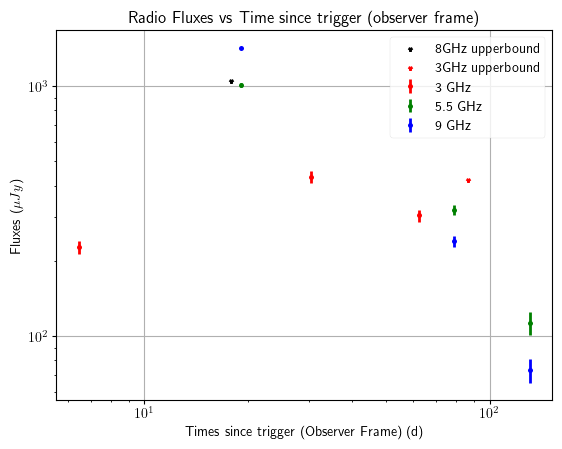

In [11]:
#Plotting our radio data:
plt.figure()
plt.errorbar(ToRadFlux[0:3], RadFlux[0:3], yerr=RadFluxE[0:3], fmt='o', capsize=5, elinewidth=2, color='red', label='3 GHz')
plt.errorbar(ToRadFlux[3:6], RadFlux[3:6], yerr=RadFluxE[3:6], fmt='o', capsize=5, elinewidth=2, color='green', label='5.5 GHz')
plt.errorbar(ToRadFlux[6:9], RadFlux[6:9], yerr=RadFluxE[6:9], fmt='o', capsize=5, elinewidth=2, color='blue', label='9 GHz')
#Upper limits:
plt.scatter(ToRadFluxUB[0], RadFluxUB[0], color='black', marker='1', linewidth=2, label='8GHz upperbound')
plt.scatter(ToRadFluxUB[1], RadFluxUB[1], color='red', marker='1', linewidth=2, label='3GHz upperbound') 
plt.title('Radio Fluxes vs Time since trigger (observer frame)')
plt.xlabel('Times since trigger (Observer Frame) (d)')
plt.ylabel('Fluxes ($\mu Jy$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

## For the $\textbf{X-ray}$ data (from Sun et al. 2025):

In [12]:
#Firstly, extracting the data from the Extended Data Table 1 in Sun et al. 2025 
XraySuntabtxt="EP240414a Data from different articles/# Extended Data Table 1 Sun et al.txt"
XraySuntab=Table.read(XraySuntabtxt, format="ascii", comment="#")
#Next, we take the values with best statistics for the different exposure times.
#Prompt best fit:
alphabestWXT=-3.1
alphabestWXTE=0.7
alphabestWXTe=0.8
#Photon index assumed and calculated for the post-prompt data points in X-rays:
alphaNP=-2.2
#Intrinsic absorption derived from the spectal fitting in this article
NintbestWXT=(7.4e21)*(u.cm**(-2))
NintbestWXTE=(4.1e21)*(u.cm**(-2))
NintbestWXTE=(3.7e21)*(u.cm**(-2))
NintbestFXT=(2.4e21)*(u.cm**(-2))
NintbestFXTE=(2.2e21)*(u.cm**(-2))
NintbestFXTe=(2.0e21)*(u.cm**(-2))
NintbestSWIFT=(2.4e21)*(u.cm**(-2))
#Galactic absorption in the direction of EP240414a from Sun et al. paper
GalAbs=3.35e20*(u.cm**(-2))

#Extracting the flux (absorbed) and times:
tst=np.array([XraySuntab['t_start_s'].value[0]])
tfin=np.array([XraySuntab['t_stop_s'].value[0]])
tstUB=np.array([])
tfinUB=np.array([])
Fluabs=np.array([XraySuntab['F_abs'].value[0]])
FluabsUB=np.array([])
FluabsE=np.array([XraySuntab['F_abs_Error'].value[0]])
Fluabse=np.array([XraySuntab['F_abs_error'].value[0]])

for j in range(1,len(XraySuntab['F_abs'].data)):
    if np.ma.is_masked(XraySuntab['F_abs_Error'].data[j]):
        FluabsUB = np.append(FluabsUB,XraySuntab['F_abs'].value[j])
        tstUB = np.append(tstUB,XraySuntab['t_start_s'].value[j])
        tfinUB = np.append(tfinUB,XraySuntab['t_stop_s'].value[j])
    else:
        if XraySuntab['instrument'].data[j]=="EP-WXT":
            continue
        else:
            Fluabs = np.append(Fluabs,XraySuntab['F_abs'].value[j])
            FluabsE = np.append(FluabsE,XraySuntab['F_abs_Error'].value[j])
            Fluabse = np.append(Fluabse,XraySuntab['F_abs_error'].value[j])
            tst = np.append(tst,XraySuntab['t_start_s'].value[j])
            tfin = np.append(tfin,XraySuntab['t_stop_s'].value[j])

#To put appropiate units
tst=tst*u.s
tfin=tfin*u.s
tstUB=tstUB*u.s
tfinUB=tfinUB*u.s

tobsXraySun=(tfin+tst)/2
e_tobsSun=tfin-tobsXraySun

tobsXraySunUB=(tfinUB+tstUB)/2
e_tobsSunUB=tfinUB-tobsXraySunUB


### Later, we asked for the unabsorbed fluxes to the authors of Sun et al. 2025, so extracting this information used below in the codes on:

In [13]:
#Extracting all the data provided:
SunXraysEmailtxt="/data/egonzalezramos/EP240414a Data from different articles/Sun et al Unabsorbed Fluxes.txt"
SunXraysEmail=Table.read(SunXraysEmailtxt, format="ascii", comment="#")

tstall=SunXraysEmail['t_obs_start(s)'].value*u.s
tfinall=SunXraysEmail['t_obs_final(s)'].value*u.s
tmeanobsall=(tfinall+tstall)/2
ordind=np.argsort(tmeanobsall)
tmeanobsall=tmeanobsall[ordind]
tstall=tstall[ordind]
tfinall=tfinall[ordind]
SunUL=SunXraysEmail['UpperLimit'][ordind]
UnabsFluxSunAll=(SunXraysEmail['UnabsFlux(ergcm-2s-1)'].value[ordind])*((u.erg)*(u.cm**-2)*(u.s**-1))
SunInstrument=SunXraysEmail['Instrument'].data[ordind]
UnabsFluxSun_eAll=SunXraysEmail['UnabsFlux_e(ergcm-2s-1)'][ordind].value
UnabsFluxSun_EAll=SunXraysEmail['UnabsFlux_E(ergcm-2s-1)'][ordind].value

#Separating detections and ULs
DetSun=(SunUL=='No')


UnabsFluxSun_e=(UnabsFluxSun_eAll[DetSun])*((u.erg)*(u.cm**-2)*(u.s**-1))
UnabsFluxSun_E=(UnabsFluxSun_EAll[DetSun])*((u.erg)*(u.cm**-2)*(u.s**-1))
UnabsFluxSun=UnabsFluxSunAll[DetSun]
tsDet=tstall[DetSun]
tfDet=tstall[DetSun]


#ULs:
UnabsFluxSunUL=UnabsFluxSunAll[~DetSun]
ULErrs=np.zeros(len(UnabsFluxSunUL))
tsUL=tstall[~DetSun]
tfUL=tstall[~DetSun]


#Caveat: after this notebook, the data is time ordered and divided in detections and no detections

### In the following cells, we check if the fluxes provided in the Extended Data Table 1 of Sun et al. 2025 are, in fact, absorbed fluxes and not unabsorbed fluxes by comparing the luminosities obtained from these data points with those presented in Figure 2b of this article (which are mentioned to be unabsorbed):

In [14]:
# Defining the functions to compute the isotropic-equivalent luminosities from the 
# integrated fluxes:
#Conversion from Mpc to cm:
MpctoCM=3.08567758128e+24
#Assuming standard LambdaCDM cosmology and displaying its characteristic parameters.
from astropy.cosmology import Planck18 as cosmo
print(cosmo, cosmo.Ode0, cosmo.Om0)
#Without K-correcting.
def ftol(redshift,flux):
    return 4*np.pi*(((cosmo.luminosity_distance(redshift).value)*(MpctoCM))**2)*flux
#with the K-correction assuming a power-law shape of the photon spectrum:
def ftolK(redshift,flux,photonindex):
    return 4*np.pi*(((cosmo.luminosity_distance(redshift).value)*(MpctoCM))**2)*flux*(1+z)**(-photonindex-2)

FlatLambdaCDM(name="Planck18", H0=67.66 km / (Mpc s), Om0=0.30966, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.04897) 0.6888463055445441 0.30966


Next, we define a function to compute the normalization constant of the flux spectrum by integrating all the points in their corresponding bands and assuming a power-law shape of the spectrum. Note that we assume this power-law spectral shape because all the post-prompt data points provided by Sun et al. 2025 are fitted only using this model:

In [15]:
# Constants used in this part:
CkeV = 1.602e-9   # erg/keV (Change of energy units from keV to erg)
hPlanck = 6.626e-27       # erg*s

# Defining because a function from E in keV to freq in Hz (useful when dealing with the 
# flux spectrum in terms of photon frequency or energy):
def Etonu(E):
    return E*CkeV/hPlanck

#Now that we have our function creating the distribution of parameters with asymmetric 
#uncertainties to perform Monte-Carlo techniques. (Ndraw is the number of points 
# for the distriution)
def propagate_to_K(F, F_e, F_E,
                   alpha, alpha_e, alpha_E,
                   E1, E2, Ndraw=200000, return_samples=False):
    #Some conditions to check for the inputs
    if F <= 0:
        raise ValueError("Unabsorbed flux must be positive.")
    #Now, defining the distributions of points for the flux and photon index inputs:
    Fv = sample_split_normal(F, F_e, F_E, Ndraw)
    alp = sample_split_normal(alpha, alpha_e, alpha_E, Ndraw)
    #Creating our empty variable for the computation of samples of the normalization constant
    if Fv.size==1:
        K_samples = np.empty_like(alp)
    else:
        K_samples = np.empty_like(Fv)
    # To handle with the special case of the photon index being equal to -2, since we perform the 
    # integration analytically for the power-law spectral shape (the power-law photon spectrum
    # is based on the one used in XSPEC, from which the integral of the flux spectrum can be 
    # calculated analytically (see MSc thesis)):
    eps = 1e-8
    mask_not2 = ~np.isclose(alp, -2.0, atol=eps)

    if mask_not2.any():
        #values of alpha different from -2
        AG = alp[mask_not2]
        #integral term:
        integral = (E2**(2.0 + AG) - E1**(2.0 + AG)) / (2.0 + AG)
        #and for the K (normalization constant) value:
        K_samples[mask_not2] = Fv[mask_not2] / (CkeV * integral)
    #Now, the same but for the case of alpha = -2
    if (~mask_not2).any():
        integral2 = np.log(E2 / E1)
        K_samples[~mask_not2] = Fv[~mask_not2] / (CkeV * integral2)

    # For presentation of the results purposes:
    def pct(arr, p):
        return np.percentile(arr, p)

    #Finally, defining the outputs.
    result = {
        'K_median': float(pct(K_samples, 50)),
        'K_16': float(pct(K_samples, 16)),
        'K_84': float(pct(K_samples, 84)),
        'K_05': float(pct(K_samples, 5)),
        'K_95': float(pct(K_samples, 95)),
        'n_draws': Ndraw,
    }
    #Returning also the distributions obtained using MC techniques:
    if return_samples:
        result['K_samples'] = K_samples
        result['F_samples'] = Fv
        result['Alpha_samples'] = alp
    return result

#And to obtain the flux per Hz at a frequency (Notice that K is computed in ergs and E
# is typically in KeV and the frequency in Hz, that is why there appears a lot of terms
# changing to appropiate units):
def K_to_Fnu(K, alpha, nu):
    return K * (hPlanck**(2.0 + alpha)) * (CkeV**(-alpha - 1.0)) * (nu**(1.0 + alpha))



#Now, to plot them with respect to the observer time, 
# we can choose the midpoint of the interval of observation:
tobsLumXray=(tst+tfin)/2
tobsLumUBXray=(tstUB+tfinUB)/2

In this part of the code, we use a GRB event from which we have the integrated fluxes and the flux densities at 10 keV to check if the codes work as expected and there are no errors in them. The result of this test is positive. This can be checked by the reader using the $Swift$ webpage for this event and comparing the data published in the webpage with the results of this notebook:

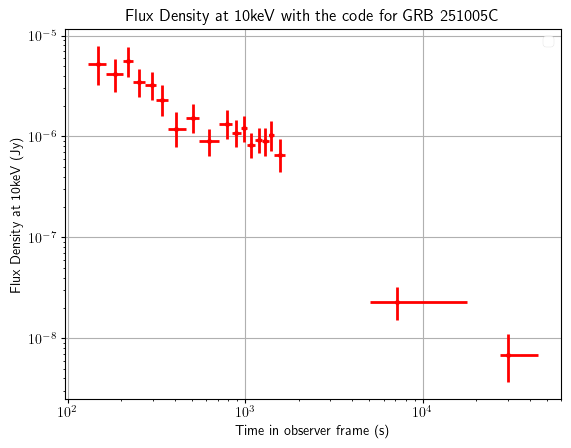

The results of this test are positive, the code works well (see Swift webpage for this event).


In [16]:
#To check if the code works (data from event GRB 251005C):
#Extracting the data from this event:
Alpchdatatxt='GRB 251005C data to check codes/Photon index data Swift CHECK GRB 251005C.txt'
Alpchdata=Table.read(Alpchdatatxt, format="ascii", comment="#")
Fluxchdatatxt="GRB 251005C data to check codes/Unabsorbed flux data Swift CHECK GRB 251005C.txt"
Fluxchdata=Table.read(Fluxchdatatxt, format="ascii", comment="#")

Kcheckdis=[]
Funabsdist=[]
alphaunabsdist=[]
#Computing the normalization constant:
for i in range(0, len(Alpchdata['tobs'].data)):
    resultscheck=propagate_to_K(Fluxchdata['Funabs'].value[i],np.abs(Fluxchdata['Funabs_e'].value[i]),Fluxchdata['Funabs_E'].value[i], -Alpchdata['alpha'].value[i],np.abs(Alpchdata['alpha_e'].value[i]), Alpchdata['alpha_E'].value[i], 0.3, 10, return_samples=True)
    Kcheckdis.append(resultscheck['K_samples'])
    Funabsdist.append(resultscheck['F_samples'])
    alphaunabsdist.append(resultscheck['Alpha_samples'])

#Now, to obtain the flux density at 10keV:
Fdens10keV=np.empty_like(Kcheckdis)
Fdens10=np.zeros(len(Alpchdata['tobs'].data))
Fdens10_e=np.zeros(len(Alpchdata['tobs'].data))
Fdens10_E=np.zeros(len(Alpchdata['tobs'].data))
tobscheck=np.zeros(len(Alpchdata['tobs'].data))
tobscheck_e=np.zeros(len(Alpchdata['tobs'].data))
tobscheck_E=np.zeros(len(Alpchdata['tobs'].data))
for i in range(0,len(Kcheckdis)):
    Fdens10keV[i]=K_to_Fnu(Kcheckdis[i],alphaunabsdist[i],Etonu(10))
    Fdens10[i]=pct(Fdens10keV[i],50)
    Fdens10_e[i]=Fdens10[i]-pct(Fdens10keV[i],16)
    Fdens10_E[i]=pct(Fdens10keV[i],84)-Fdens10[i]
    tobscheck[i]=Alpchdata['tobs'].value[i]
    tobscheck_e[i]=np.abs(Alpchdata['tobs_e'].value[i])
    tobscheck_E[i]=Alpchdata['tobs_E'].value[i]

Fdens10=Fdens10*(u.erg/((u.cm**2)*u.s*u.Hz))
Fdens10_e=Fdens10_e*(u.erg/((u.cm**2)*u.s*u.Hz))
Fdens10_E=Fdens10_E*(u.erg/((u.cm**2)*u.s*u.Hz))
Fplot=Fdens10.to(u.Jy)
Fplot_e=Fdens10_e.to(u.Jy)
Fplot_E=Fdens10_E.to(u.Jy)

#Plotting the results:
plt.figure()
plt.errorbar(tobscheck,Fplot, yerr=np.vstack([Fplot_e, Fplot_E]), xerr=np.vstack([tobscheck_e,tobscheck_E]), fmt='o', capsize=5, elinewidth=2, color='red')
plt.title('Flux Density at 10keV with the code for GRB 251005C')
plt.xlabel('Time in observer frame (s)')
plt.ylabel('Flux Density at 10keV (Jy)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

print('The results of this test are positive, the code works well (see Swift webpage for this event).')


Next, we calculate with this code the flux density from the data found in Extended Data Table 1 of Sun et al. 2025. Lastly, we compute the isotropic-equivalent luminosity from the flux density to visually compare with the data presented in Figure 2b.

In [17]:
# Then, with this absorbed flux we can compute the flux density (at 1keV) 
# or normalization constant as:
AlphaSamples=[]
AlphaSamplesUB=[]
KSamplesSun=[]
KSamplesSunUB=[]

for i in range(0,(len(Fluabs)+len(FluabsUB))):
    if i==0: #WXT point
        resultsWXT=propagate_to_K(Fluabs[i],Fluabse[i],FluabsE[i],alphabestWXT,alphabestWXTe,alphabestWXTE,0.5,4,return_samples=True)
        KSamplesSun.append(resultsWXT['K_samples'])
        AlphaSamples.append(resultsWXT['Alpha_samples'])
    if i>0 and i<3: #First two FXT points following the extended data from Sun et al. 2025
        resultsFXT=propagate_to_K(Fluabs[i],Fluabse[i],FluabsE[i],alphaNP,0.4,0.3,0.5,10,return_samples=True)
        KSamplesSun.append(resultsFXT['K_samples'])
        AlphaSamples.append(resultsFXT['Alpha_samples'])
    if i>3: #Swift points which are UL except one point at position 3:
        if i==4:
            resultsSwift=propagate_to_K(Fluabs[-1],Fluabse[-1],FluabsE[-1],alphaNP,0,0,0.3,10,return_samples=True)
            KSamplesSun.append(resultsSwift['K_samples'])
            AlphaSamples.append(resultsSwift['Alpha_samples'])
        else:
            resultsSwiftUB=propagate_to_K(FluabsUB[i-len(Fluabs)],0,0,alphaNP,0,0,0.3,10,return_samples=True)
            KSamplesSunUB.append(resultsSwiftUB['K_samples'])
            AlphaSamplesUB.append(resultsSwiftUB['Alpha_samples'])

    if i==3: #UL in FXT
        resultsFXTUB=propagate_to_K(FluabsUB[0],0,0,alphaNP,0.4,0.3,0.5,10,return_samples=True)
        KSamplesSunUB.append(resultsFXTUB['K_samples'])
        AlphaSamplesUB.append(resultsFXTUB['Alpha_samples'])

#The flux densities at 1keV for these fluxes are:
FluxMed=np.zeros(len(Fluabs))
FluxMed_e=np.zeros(len(Fluabs))
FluxMed_E=np.zeros(len(Fluabs))
FluxMedUB=np.zeros(len(FluabsUB))
for i in range(0,(len(Fluabs)+len(FluabsUB))):
    if i<len(Fluabs):
        FluxMed[i]=pct(K_to_Fnu(KSamplesSun[i],AlphaSamples[i],Etonu(1)),50)
        FluxMed_e[i]=FluxMed[i]-pct(K_to_Fnu(KSamplesSun[i],AlphaSamples[i],Etonu(1)),16)
        FluxMed_E[i]=pct(K_to_Fnu(KSamplesSun[i],AlphaSamples[i],Etonu(1)),84)-FluxMed[i]
    else:
        FluxMedUB[i-len(Fluabs)]=pct(K_to_Fnu(KSamplesSunUB[i-len(Fluabs)],AlphaSamplesUB[i-len(Fluabs)],Etonu(1)),50)

FluxMed=FluxMed*(u.erg/((u.cm**2)*u.s*u.Hz))
FluxMed_e=FluxMed_e*(u.erg/((u.cm**2)*u.s*u.Hz))
FluxMed_E=FluxMed_E*(u.erg/((u.cm**2)*u.s*u.Hz))
FluxMedUB=FluxMedUB*(u.erg/((u.cm**2)*u.s*u.Hz))

FluxMeduJy=FluxMed.to(u.uJy)
FluxMeduJy_e=FluxMed_e.to(u.uJy)
FluxMeduJy_E=FluxMed_E.to(u.uJy)
FluxMeduJyUB=FluxMedUB.to(u.uJy)


#Now, computing the absorbed flux by integrating the flux density from 0.5 to 10keV:
FINT=[]
FINTUB=[]

eps = 1e-8

#To handle with the special case of the photon index being equal to -2:
for i in range(0,(len(Fluabs)+len(FluabsUB))):
    if i<len(Fluabs):
        mask_not2 = ~np.isclose(AlphaSamples[i], -2.0, atol=eps)
        COMSAMP=np.empty_like(KSamplesSun[i])
        if mask_not2.any():
            #values of alpha different from -2
            AG = AlphaSamples[i][mask_not2]
            #integral term:
            integral = (10**(2.0 + AG) - 0.5**(2.0 + AG)) / (2.0 + AG)
            #and for the K value:
            COMSAMP[mask_not2] = KSamplesSun[i][mask_not2]*(CkeV * integral)
        #Now, the same but for the case of alpha = -2
        if (~mask_not2).any():
            integral2 = np.log(10 / 0.5)
            COMSAMP[~mask_not2] = KSamplesSun[i][~mask_not2]*(CkeV * integral2)
        FINT.append(COMSAMP)
    #And for the upper limits:
    else:
        if i-len(Fluabs)==0:
            mask_not2 = ~np.isclose(AlphaSamplesUB[i-len(Fluabs)], -2.0, atol=eps)
            COMSAMP=np.empty_like(AlphaSamplesUB[i-len(Fluabs)])
            if mask_not2.any():
                #values of alpha different from -2
                AG = AlphaSamplesUB[i-len(Fluabs)][mask_not2]
                #integral term:
                integral = (10**(2.0 + AG) - 0.5**(2.0 + AG)) / (2.0 + AG)
                #and for the K value:
                COMSAMP[mask_not2] = KSamplesSunUB[i-len(Fluabs)][mask_not2]*(CkeV * integral)
            #Now, the same but for the case of alpha = -2
            if (~mask_not2).any():
                integral2 = np.log(10 / 0.5)
                COMSAMP[~mask_not2] = KSamplesSunUB[i-len(Fluabs)][~mask_not2]*(CkeV * integral2)
            FINTUB.append(COMSAMP)
        else:
            COMSAMP= KSamplesSunUB[i-len(Fluabs)]*(CkeV * ((10**(2.0 + AlphaSamplesUB[i-len(Fluabs)]) - 0.5**(2.0 + AlphaSamplesUB[i-len(Fluabs)])) / (2.0 + AlphaSamplesUB[i-len(Fluabs)])))
            FINTUB.append(COMSAMP)


#Now, going from integrated fluxes to luminosities:
#Creating the distribution of redshifts:
zdist=sample_split_normal(z,ez,ez,200000)

#Calculating the distribution of luminosities:
LCALC=np.array([])
LCALCe=np.array([])
LCALCE=np.array([])
LCALCUB=np.array([])
LCALCK=np.array([])
LCALCKe=np.array([])
LCALCKE=np.array([])
LCALCKUB=np.array([])

# Notice that we calculate both K-correcting and not K-correcting to study how the K-correction 
# affects the final luminosities and because it is not specified in Sun et al. 2025 if the
# luminosities presented in Figure 2b are in the rest-frame or not:
for i in range(0,(len(Fluabs)+len(FluabsUB))):
    if i<len(Fluabs):
        LCALC=np.append(LCALC,pct(ftol(zdist,FINT[i]),50))
        LCALCe=np.append(LCALCe,LCALC[i]-pct(ftol(zdist,FINT[i]),16))
        LCALCE=np.append(LCALCE,pct(ftol(zdist,FINT[i]),84)-LCALC[i])
        LCALCK=np.append(LCALCK,pct(ftolK(zdist,FINT[i],AlphaSamples[i]),50))
        LCALCKe=np.append(LCALCKe,LCALCK[i]-pct(ftolK(zdist,FINT[i],AlphaSamples[i]),16))
        LCALCKE=np.append(LCALCKE,pct(ftolK(zdist,FINT[i],AlphaSamples[i]),84)-LCALCK[i])
    if i>=len(Fluabs):
        LCALCUB=np.append(LCALCUB,pct(ftol(zdist,FINTUB[i-len(Fluabs)]),50))
        LCALCKUB=np.append(LCALCKUB,pct(ftolK(zdist,FINTUB[i-len(Fluabs)],AlphaSamplesUB[i-len(Fluabs)]),50))

# These luminosities are presented later in the notebook and we observed that they are different 
# from the ones presented in Figure 2b, which indicate that the fluxes provided by the Extended 
# Data Table 1 in this article are absorbed fluxes, as mentioned in this table.

### Now, in the same way but this time for the unabsorbed fluxes provided directly by the authors of Sun et al. 2025:

WXT
WXT
WXT
FXT
FXT
FXT


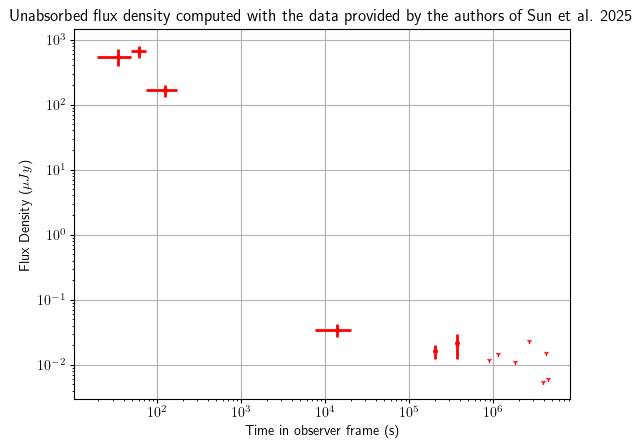

In [18]:
photonindTab=np.array([-3.9, -2.7, -3.0, -2.2, -2.2, -2.2, -2.2, -2.2, -2.2, -2.2, -2.2, -2.2, -2.2])
photonindTab_e=np.array([0.9, 0.6, 0.7, 0.4, 0.4, 0.4, 0, 0, 0, 0, 0, 0, 0])
photonindTab_E=np.array([0.9, 0.5, 0.7, 0.3, 0.3, 0.3, 0, 0, 0, 0, 0, 0, 0])

photonindTab=photonindTab[ordind]
photonindTab_e=photonindTab_e[ordind]
photonindTab_E=photonindTab_E[ordind]

#Calculating the normalization constant of the flux density:
AlphaSamplesSun=[]
KSamplesSunEmail=[]

for i in range(0,len(UnabsFluxSunAll)):
    if SunInstrument[i]=='EP-WXT':
        results=propagate_to_K(UnabsFluxSunAll[i].value, UnabsFluxSun_eAll[i], UnabsFluxSun_EAll[i], photonindTab[i], photonindTab_e[i], photonindTab_E[i], 0.5, 4, return_samples=True)
        print('WXT')
    elif SunInstrument[i]=='EP-FXT':
        results=propagate_to_K(UnabsFluxSunAll[i].value, UnabsFluxSun_eAll[i], UnabsFluxSun_EAll[i], photonindTab[i], photonindTab_e[i], photonindTab_E[i], 0.5, 10, return_samples=True)
        print('FXT')
    else:
        results=propagate_to_K(UnabsFluxSunAll[i].value, UnabsFluxSun_eAll[i], UnabsFluxSun_EAll[i], photonindTab[i], photonindTab_e[i], photonindTab_E[i], 0.3, 10, return_samples=True)
    AlphaSamplesSun.append(results['Alpha_samples'])
    KSamplesSunEmail.append(results['K_samples'])

#So, calculating the flux density (at 1 keV):
FluxdensSunE=np.zeros(len(UnabsFluxSunAll))
FluxdensSunE_e=np.zeros(len(UnabsFluxSunAll))
FluxdensSunE_E=np.zeros(len(UnabsFluxSunAll))


for i in range(0,len(UnabsFluxSunAll)):
    FluxdensSunE[i]=pct(K_to_Fnu(KSamplesSunEmail[i],AlphaSamplesSun[i],Etonu(1)),50)
    FluxdensSunE_e[i]=FluxdensSunE[i]-pct(K_to_Fnu(KSamplesSunEmail[i],AlphaSamplesSun[i],Etonu(1)),16)
    FluxdensSunE_E[i]=pct(K_to_Fnu(KSamplesSunEmail[i],AlphaSamplesSun[i],Etonu(1)),84)-FluxdensSunE[i]

#Changing the units of the flux density to microJanskys:
FluxdensSunE=(FluxdensSunE*(u.erg/((u.cm**2)*u.s*u.Hz))).to(u.uJy)
FluxdensSunE_e=(FluxdensSunE_e*(u.erg/((u.cm**2)*u.s*u.Hz))).to(u.uJy)
FluxdensSunE_E=(FluxdensSunE_E*(u.erg/((u.cm**2)*u.s*u.Hz))).to(u.uJy)
FluxdensSunE_e[~DetSun]=0
FluxdensSunE_E[~DetSun]=0


#And for the unabsorbed luminosities to compare them to Figure 2.b):
#Integrating in the 0.5-10 keV band, which is the one in which the Figure 2.b) is defined:
#To handle with the special case of the photon index being equal to -2
eps=1e-8
FINTLUM=[]
for i in range(0,(len(FluxdensSunE))):
    mask_not2 = ~np.isclose(AlphaSamplesSun[i], -2.0, atol=eps)
    COMSAMP=np.empty_like(KSamplesSunEmail[i])
    if mask_not2.any():
        #values of alpha different from -2
        AG = AlphaSamplesSun[i][mask_not2]
        #integral term:
        integral = (10**(2.0 + AG) - 0.5**(2.0 + AG)) / (2.0 + AG)
        #and for the K value:
        COMSAMP[mask_not2] = KSamplesSunEmail[i][mask_not2]*(CkeV * integral)
    #Now, the same but for the case of alpha = -2
    if (~mask_not2).any():
        integral2 = np.log(10 / 0.5)
        COMSAMP[~mask_not2] = KSamplesSunEmail[i][~mask_not2]*(CkeV * integral2)
    FINTLUM.append(COMSAMP)




#Computing the isotropic-equivalent luminosities (K-correcting and not again):
UnabsFluxDist=[]

LCALCSun=np.array([])
LCALCSun_e=np.array([])
LCALCSun_E=np.array([])

LCALCKSun=np.array([])
LCALCKSun_e=np.array([])
LCALCKSun_E=np.array([])

for i in range(0, len(UnabsFluxSunAll)):
    LCALCSun=np.append(LCALCSun,pct(ftol(zdist,FINTLUM[i]),50))
    LCALCSun_e=np.append(LCALCSun_e,LCALCSun[i] - pct(ftol(zdist,FINTLUM[i]),16))
    LCALCSun_E=np.append(LCALCSun_E, pct(ftol(zdist,FINTLUM[i]),84)- LCALCSun[i])

    LCALCKSun=np.append(LCALCKSun,pct(ftolK(zdist,FINTLUM[i], AlphaSamplesSun[i]),50))
    LCALCKSun_e=np.append(LCALCKSun_e,LCALCKSun[i] - pct(ftolK(zdist,FINTLUM[i],AlphaSamplesSun[i]),16))
    LCALCKSun_E=np.append(LCALCKSun_E, pct(ftolK(zdist,FINTLUM[i], AlphaSamplesSun[i]),84)- LCALCKSun[i])


#And plotting this unabsorbed flux densities:
plt.figure()
plt.errorbar(tmeanobsall[DetSun], FluxdensSunE[DetSun], yerr=np.vstack([FluxdensSunE_e[DetSun], FluxdensSunE_E[DetSun]]), xerr=tfinall[DetSun]-tmeanobsall[DetSun], fmt='o', capsize=5, elinewidth=2, color='red')
plt.scatter(tmeanobsall[~DetSun], FluxdensSunE[~DetSun], color='r', marker='1')
plt.title('Unabsorbed flux density computed with the data provided by the authors of Sun et al. 2025')
plt.xlabel('Time in observer frame (s)')
plt.ylabel('Flux Density ($\mu Jy$)')
plt.xscale('log')
plt.yscale('log')
plt.grid()
plt.show()

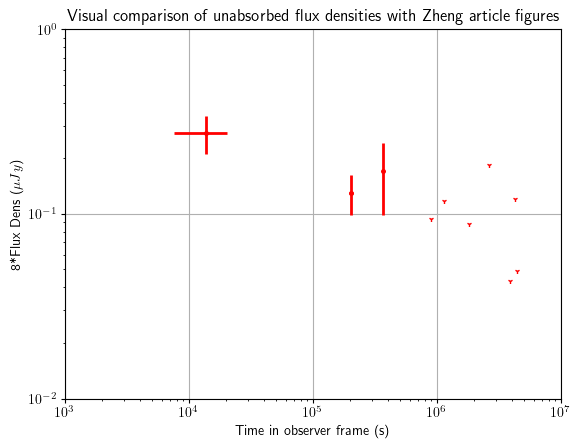

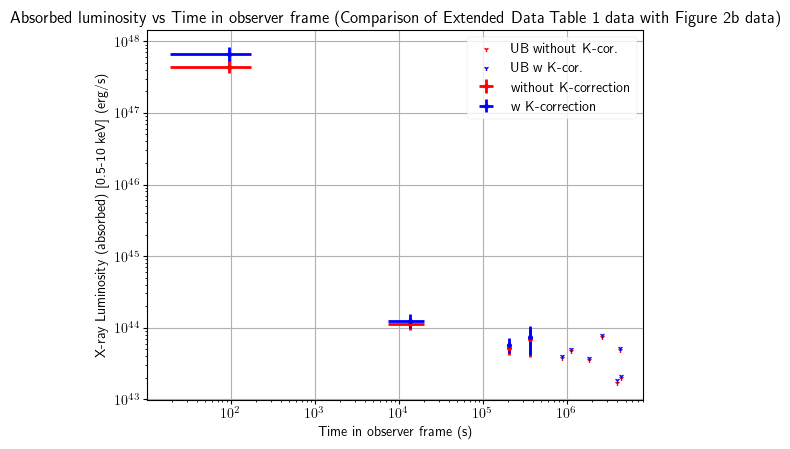

In [19]:
#Plotting our the last flux density for X-rays obtained and comparing it with 
# the one presented in Zheng et al. 2025 to check the data obtained:
plt.figure()
plt.errorbar(tmeanobsall[DetSun], 8*FluxdensSunE[DetSun], yerr=np.vstack([8*FluxdensSunE_e[DetSun], 8*FluxdensSunE_E[DetSun]]), xerr=tfinall[DetSun]-tmeanobsall[DetSun], fmt='o', capsize=5, elinewidth=2, color='red')
plt.scatter(tmeanobsall[~DetSun], 8*FluxdensSunE[~DetSun], color='r', marker='1')
plt.title('Visual comparison of unabsorbed flux densities with Zheng article figures')
plt.xlabel('Time in observer frame (s)')
plt.ylabel('8*Flux Dens ($\mu Jy$)')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e-2,1)
plt.xlim(1e3,1e7)
plt.grid()
plt.show()


#Plotting our Luminosity for X-ray:
plt.figure()
plt.errorbar(tobsLumXray, LCALC, yerr=np.vstack([LCALCe, LCALCE]), xerr=tfin-tobsLumXray, fmt='o', capsize=5, elinewidth=2, color='red', label='without K-correction')
plt.errorbar(tobsLumXray, LCALCK, yerr=np.vstack([LCALCKe, LCALCKE]), xerr=tfin-tobsLumXray, fmt='o', capsize=5, elinewidth=2, color='blue', label='w K-correction')
plt.scatter(tobsLumUBXray, LCALCUB, color='r', marker='1', label='UB without K-cor.')
plt.scatter(tobsLumUBXray, LCALCKUB, color='b', marker='1', label='UB w K-cor.')
plt.title('Absorbed luminosity vs Time in observer frame (Comparison of Extended Data Table 1 data with Figure 2b data)')
plt.xlabel('Time in observer frame (s)')
plt.ylabel('X-ray Luminosity (absorbed) [0.5-10 keV] (erg/s)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()


### Now, in the following cells, I used the isotropic-equivalent luminosities from Figure 2b in Sun et al. 2025 (data extracted using WebPlotDigitizer for this figure), to obtain the X-ray flux densities at 1keV. Furthermore, we compare the results of this method with the flux densities obtained from the data provided by the authors and we visually compare it with the flux densities presented in Zheng et al. 2025.

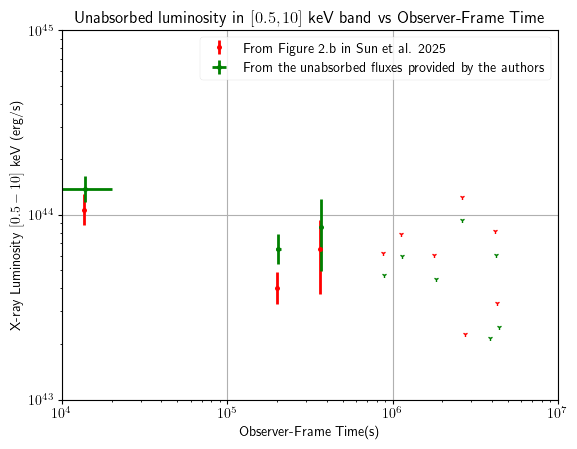

In [20]:
#Extracting the data from the Sun et al. 2025 figure:
SunLtext='EP240414a Data from different articles/Figure b) Sun et al data points.txt'
SunL = Table.read(SunLtext, format="ascii", comment="#")

# We are going to be interested on the FXT/Swift points and the WXT point with best statistics:
# However, note that we are going to model the afterglow, so the prompt points are not taken
# into account in this part of the code.


tobsLumUBXray.sort()
tobsLumXray.sort()
tfin.sort()
tst.sort()
tfinUB.sort()
tstUB.sort()

LumUNABS=np.array([])
LumUBUNABS=np.array([])
tobsXraySunPlot=np.array([])
tobsXraySunPlotUB=np.array([])
for i in range(7,len(SunL["Lum_abs_cgs"].data)):
    if i==8:
        continue
    if i<12:
        LumUNABS=np.append(LumUNABS,SunL["Lum_abs_cgs"][i])
        tobsXraySunPlot=np.append(tobsXraySunPlot,SunL["t_mean_obs_s"][i])
    else:
        LumUBUNABS=np.append(LumUBUNABS,SunL["Lum_abs_cgs"].value[i])
        tobsXraySunPlotUB=np.append(tobsXraySunPlotUB,SunL["t_mean_obs_s"][i])

tobsXraySunPlot[0]=tobsLumXray[0].value

#For the uncertainties in the luminosity, since it is not possible to resolve the errors from the Figure.
#I am going to assume the same relative uncertainty in our data as the one for the absorbed 
# flux in Sun et al. 2025 Extended Data Table 1:
RELUNCFLUX_E=np.array([1.3/6.5, 0.4/ 1.8, 1.9/8.3, 0.6/1.4])
RELUNCFLUX_e=np.array([1.0/6.5, 0.3/ 1.8, 1.5/8.3, 0.6/1.4])
tobsXraySunPlot=tobsXraySunPlot*(1+z) #From rest to observer frame
tobsXraySunPlotUB=tobsXraySunPlotUB*(1+z) #From rest to observer frame



#Now, plotting our unabsorbed X-ray Luminosities, to compare them with the Figure 2b of Sun et al. 2025:
plt.figure()
plt.errorbar(tobsXraySunPlot, LumUNABS, yerr=np.vstack([RELUNCFLUX_e*LumUNABS,RELUNCFLUX_E*LumUNABS]), fmt='o', capsize=5, elinewidth=2, color='red', label='From Figure 2.b in Sun et al. 2025')
plt.scatter(tobsXraySunPlotUB, LumUBUNABS, color='r', marker='1')
# plt.errorbar(tmeanobsall[DetSun], LCALCSun[DetSun], yerr=np.vstack([LCALCSun_e[DetSun], LCALCSun_E[DetSun]]), xerr=tfinall[DetSun]-tmeanobsall[DetSun], fmt='o', capsize=5, elinewidth=2, color='blue', label='From the unabsorbed flux provided by Sun (w/ K-corr) NOT in [0.5,10] keV')
# plt.scatter(tmeanobsall[~DetSun], LCALCSun[~DetSun], color='blue', marker='1')
plt.errorbar(tmeanobsall[DetSun], LCALCKSun[DetSun], yerr=np.vstack([LCALCKSun_e[DetSun], LCALCKSun_E[DetSun]]), xerr=tfinall[DetSun]-tmeanobsall[DetSun], fmt='o', capsize=5, elinewidth=2, color='green', label='From the unabsorbed fluxes provided by the authors')
plt.scatter(tmeanobsall[~DetSun], LCALCKSun[~DetSun], color='green', marker='1')
plt.title('Unabsorbed luminosity in $[0.5, 10]$ keV band vs Observer-Frame Time')
plt.xlabel('Observer-Frame Time(s)')
plt.ylabel(rf'X-ray Luminosity $[0.5-10]$ keV (erg/s)')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1e43,1e45)
plt.xlim(1e4,1e7)
plt.legend()
plt.grid()
plt.show()


In [21]:
#Now, from unabsorbed luminosities, to fluxes:
def LtoFK(redshift,luminosity,photonindex):
    return luminosity*((1+z)**(photonindex+2))/(4*np.pi*(((cosmo.luminosity_distance(redshift).value)*MpctoCM)**2))
#Without K-correction:
def LtoF(redshift,luminosity):
    return luminosity/(4*np.pi*(((cosmo.luminosity_distance(redshift).value)*MpctoCM)**2))

# Creating a function to propagate the error to the unabsorbed flux from the isotropic-equivalent luminosities:
def propagate_to_Funabs(Lumi, Lumi_e, Lumi_E,
                   alpha, alpha_e, alpha_E,
                   redshi, redshi_e, redshi_E, Ndraw=200000, return_samples=False):
    #Creating the distribution with the uncertainties for each parameter:
    Ls = sample_split_normal(Lumi, Lumi_e, Lumi_E, Ndraw)
    alps = sample_split_normal(alpha, alpha_e, alpha_E, Ndraw)
    zs = sample_split_normal(redshi, redshi_e, redshi_E, Ndraw)
    #Calculating the flux distribution (with the K-correction and assuming a power-law shape for the spectrum!):
    Fsuns=LtoFK(zs,Ls,alps)


    #Finally, defining the outputs.
    result = {
        'F_median': float(pct(Fsuns, 50)),
        'F_16': float(pct(Fsuns, 16)),
        'F_84': float(pct(Fsuns, 84)),
        'F_05': float(pct(Fsuns, 5)),
        'F_95': float(pct(Fsuns, 95)),
        'n_draws': Ndraw,
    }
    if return_samples:
        result['F_samples'] = Fsuns
        result['L_samples'] = Ls
        result['Alpha_samples'] = alps
        result['Z_samples'] = zs
    return result


#Now, computing the unabsorbed flux for each luminosity point and the normalization constant at the same time:
FUNABSdist=[]
FubUNABSdist=[]
alphadist=[]
alphadistUB=[]
KSamples=[]
KSamplesUB=[]

for i in range(0,(len(LumUNABS)+len(LumUBUNABS))):
    if i==0: #WXT point:
        resultsWXT=propagate_to_Funabs(LumUNABS[i],0,0,alphabestWXT,alphabestWXTe,alphabestWXTE,z,ez,0,return_samples=True)
        FUNABSdist.append(resultsWXT['F_samples'])
        alphadist.append(resultsWXT['Alpha_samples'])
    if i>0 and i<3: #First two FXT points following the Extended Data Table 1 from Sun et al. 2025
        resultsFXT=propagate_to_Funabs(LumUNABS[i],0,0,alphaNP,0.4,0.3,z,ez,0,return_samples=True)
        FUNABSdist.append(resultsFXT['F_samples'])
        alphadist.append(resultsFXT['Alpha_samples'])
    if i>=3 and i!=8: #Swift points which are UL except one point at position 3 :
        if i==3:
            resultsSwift=propagate_to_Funabs(LumUNABS[-1],0,0,alphaNP,0,0,z,ez,0,return_samples=True)
            FUNABSdist.append(resultsSwift['F_samples'])
            alphadist.append(resultsSwift['Alpha_samples'])
        else:
            #for the last value:
            if i==(len(LumUNABS)+len(LumUBUNABS)-1):
                resultsSwiftUB=propagate_to_Funabs(LumUBUNABS[-1],0,0,alphaNP,0,0,z,ez,0,return_samples=True)
                FubUNABSdist.append(resultsSwiftUB['F_samples'])
                alphadistUB.append(resultsSwiftUB['Alpha_samples'])

            else:
                resultsSwiftUB=propagate_to_Funabs(LumUBUNABS[int(1+i-len(LumUNABS))],0,0,alphaNP,0,0,z,ez,0,return_samples=True)
                FubUNABSdist.append(resultsSwiftUB['F_samples'])
                alphadistUB.append(resultsSwiftUB['Alpha_samples'])
    if i==8: #UL in FXT
        resultsFXTUB=propagate_to_Funabs(LumUBUNABS[0],0,0,alphaNP,0.4,0.3,z,ez,0,return_samples=True)
        FubUNABSdist.append(resultsFXTUB['F_samples'])
        alphadistUB.append(resultsFXTUB['Alpha_samples'])


#Finally, computing the normalization constant, since we already have the distribution for the 
#unabsorbed flux and the distribution for the photon index in each case:

Kdist=[]
KdistUB=[]
eps = 1e-8

#To handle with the special case of the photon index being equal to -2
for i in range(0,(len(LumUNABS)+len(LumUBUNABS))):
    if i<len(LumUNABS):
        mask_not2 = ~np.isclose(alphadist[i], -2.0, atol=eps)
        COMSAMP=np.empty_like(FUNABSdist[i])
        if mask_not2.any():
            #values of alpha different from -2
            AG = alphadist[i][mask_not2]
            #integral term:
            integral = (10**(2.0 + AG) - 0.5**(2.0 + AG)) / (2.0 + AG)
            #and for the flux values:
            COMSAMP[mask_not2] = FUNABSdist[i][mask_not2]/(CkeV * integral)
        #Now, the same but for the case of alpha = -2
        if (~mask_not2).any():
            integral2 = np.log(10 / 0.5)
            COMSAMP[~mask_not2] = FUNABSdist[i][~mask_not2]/(CkeV * integral2)
        Kdist.append(COMSAMP)
    #and for the upper limits
    else:
        if i-len(LumUNABS)==0:
            mask_not2 = ~np.isclose(alphadistUB[i-len(LumUNABS)], -2.0, atol=eps)
            COMSAMP=np.empty_like(alphadistUB[i-len(LumUNABS)])
            if mask_not2.any():
                #values of alpha different from -2
                AG = alphadistUB[i-len(LumUNABS)][mask_not2]
                #integral term:
                integral = (10**(2.0 + AG) - 0.5**(2.0 + AG)) / (2.0 + AG)
                #and for the flux values:
                COMSAMP[mask_not2] = FubUNABSdist[i-len(LumUNABS)][mask_not2]/(CkeV * integral)
            #Now, the same but for the case of alpha = -2
            if (~mask_not2).any():
                integral2 = np.log(10 / 0.5)
                COMSAMP[~mask_not2] = FubUNABSdist[i-len(LumUNABS)][~mask_not2]/(CkeV * integral2)
            KdistUB.append(COMSAMP)
        else:
            COMSAMP= FubUNABSdist[i-len(LumUNABS)]/(CkeV * ((10**(2.0 + alphadistUB[i-len(LumUNABS)]) - 0.5**(2.0 + alphadistUB[i-len(LumUNABS)])) / (2.0 + alphadistUB[i-len(LumUNABS)])))
            KdistUB.append(COMSAMP)

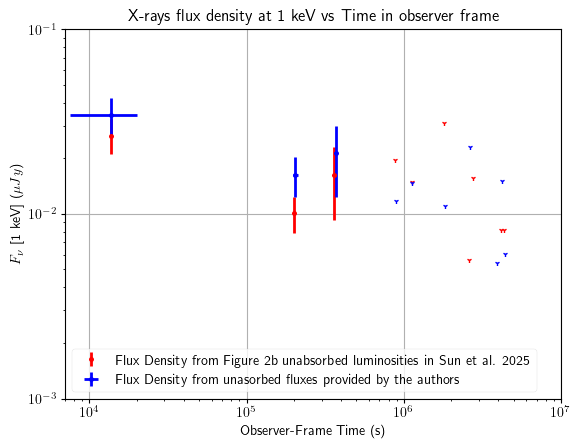

In this plot, we can see the difference between the flux densities at 1keV computed from the Figure 2b isotropic-equivalent unabsorbed luminosities and the ones derived from the unabsorbed fluxes provided directly from the authors of Sun et al. 2025. This difference, which is small but important for the light curve fitting because of the little number of X-ray points, justifies the need of asking for the X-ray data to the authors.


In [22]:
#Now that we found the distribution of the normalization constant, we can obtain the unabsorbed
#flux density in X-rays evaluated at 1KeV:
Fdens=np.array([])
Fdens_e=np.array([])
Fdens_E=np.array([])
FdensUB=np.array([])

for i in range(0,len(LumUNABS)):
    Fdens=np.append(Fdens,pct(hPlanck*Kdist[i],50))
    Fdens_e=np.append(Fdens_e,Fdens[i]-pct(hPlanck*Kdist[i],16))
    Fdens_E=np.append(Fdens_E,pct(hPlanck*Kdist[i],84)-Fdens[i])
for i in range(0,len(LumUBUNABS)):
    FdensUB=np.append(FdensUB,pct(hPlanck*KdistUB[i],50))


Fdens=Fdens*(u.erg/(u.s*(u.cm**2)*u.Hz))
Fdens_e=Fdens_e*(u.erg/(u.s*(u.cm**2)*u.Hz))
Fdens_E=Fdens_E*(u.erg/(u.s*(u.cm**2)*u.Hz))
FdensUB=FdensUB*(u.erg/(u.s*(u.cm**2)*u.Hz))
Fdens=Fdens.to(u.uJy)
Fdens_e=Fdens_e.to(u.uJy)
Fdens_E=Fdens_E.to(u.uJy)
FdensUB=FdensUB.to(u.uJy)

#Adding in quadrature the 'systematic error' obtained from the relative 
#error of the unabsorbed flux published in the extended data table:
Fdens_e=np.hypot(Fdens_e, RELUNCFLUX_e*Fdens)
Fdens_E=np.hypot(Fdens_E, RELUNCFLUX_E*Fdens)

#Now, plotting our flux density:
plt.figure()
plt.errorbar(tobsXraySunPlot[1:], Fdens[1:], yerr=np.vstack([Fdens_e[1:], Fdens_E[1:]]), fmt='o', capsize=5, elinewidth=2, color='red', label='Flux Density from Figure 2b unabsorbed luminosities in Sun et al. 2025')
plt.scatter(tobsXraySunPlotUB, FdensUB, color='r', marker='1')
plt.errorbar(tmeanobsall[DetSun], FluxdensSunE[DetSun], yerr=np.vstack([FluxdensSunE_e[DetSun], FluxdensSunE_E[DetSun]]), xerr=tfinall[DetSun]-tmeanobsall[DetSun], fmt='o', capsize=5, elinewidth=2, color='blue', label='Flux Density from unasorbed fluxes provided by the authors')
plt.scatter(tmeanobsall[~DetSun], FluxdensSunE[~DetSun], color='b', marker='1')
plt.title('X-rays flux density at 1 keV vs Time in observer frame')
plt.xlabel('Observer-Frame Time (s)')
plt.ylabel(rf'$F_{{\nu}}$ [1 keV] ($\mu Jy$)')
plt.xscale('log')
plt.yscale('log')
plt.xlim(7e3,1e7)
plt.ylim(1e-3,1e-1)
plt.legend()
plt.grid()
plt.show()

print('In this plot, we can see the difference between the flux densities at 1keV computed from the Figure 2b isotropic-equivalent unabsorbed luminosities and the ones derived from the unabsorbed fluxes provided directly from the authors of Sun et al. 2025. This difference, which is small but important for the light curve fitting because of the little number of X-ray points, justifies the need of asking for the X-ray data to the authors.')

## Lastly, for the $\textbf{Infrared}$ (IR) and $\textbf{Ultraviolet}$ (UV) data obtained from van Dalen et al. 2025 and Srivastav et al. 2025:

In these cells, there are less comments next to the codes because the procedure is completely analogous to the one followed in the optical data cells:

At the position  39 there is an upper bound for the filter Ks
At the position  3 there is an upper bound for the filter R
At the position  10 there is an upper bound for the filter J
F_rel for IR/UV magnitudes data in % for van Dalen et al. 2025 data is [1.30906481 0.         1.51392237 0.         0.         0.
 1.39402181]


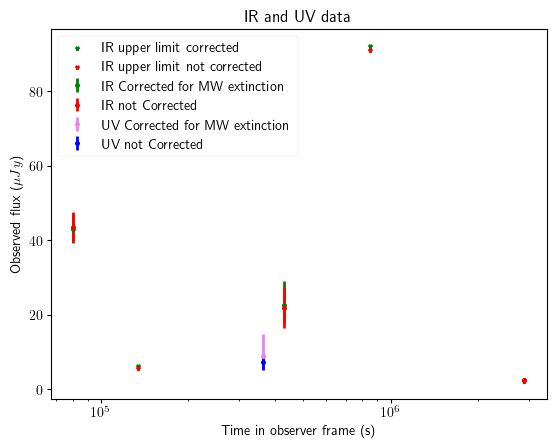

In [23]:
# Extracting and ordering the IR/UV data:
tobsIR=np.array([])
Filter=[]
FilterUV=[]
IRmag=np.array([])
IRmagE=np.array([])
sourceIR=[]
sourceUV=[]
sourceIRUB=[]

for j in range(len(pmetry['ABMag'].data)):
    if pmetry['Filter'].data[j]=='Ks':
        if np.ma.is_masked(pmetry['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter Ks')
        else:
            IRmag = np.append(IRmag,pmetry['ABMag'].value[j])
            sourceIR.append('van Dalen et al. 2025')
            IRmagE = np.append(IRmagE,pmetry['e_ABMag'].value[j])
            tobsIR = np.append(tobsIR,pmetry['SinceTriggerObserved'].value[j])
            Filter.append(pmetry['Filter'].data[j])
    if pmetry['Filter'].data[j]=='J':
        if np.ma.is_masked(pmetry['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter J')
        else:
            IRmag = np.append(IRmag,pmetry['ABMag'].value[j])
            sourceIR.append('van Dalen et al. 2025')
            IRmagE = np.append(IRmagE,pmetry['e_ABMag'].value[j])
            tobsIR = np.append(tobsIR,pmetry['SinceTriggerObserved'].value[j])
            Filter.append(pmetry['Filter'].data[j])
    if pmetry['Filter'].data[j]=='uvm2':
        UVMAG = pmetry['ABMag'].value[j]
        sourceUV.append('van Dalen et al. 2025')
        UVMAGE = pmetry['e_ABMag'].value[j]
        tobsUV=pmetry['SinceTriggerObserved'].value[j]*u.d
        FilterUV.append(pmetry['Filter'].data[j])

#For Srivastav et al. 2025 data: 
for j in range(len(Srivas['mag'].data)):
    if Srivas['Filter'].data[j]=='y':
        if np.ma.is_masked(Srivas['e_mag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter y')
        else:
            IRmag = np.append(IRmag,Srivas['mag'].value[j])
            sourceIR.append('Srivastav et al. 2025')
            IRmagE = np.append(IRmagE,Srivas['e_mag'].value[j])
            tobsIR = np.append(tobsIR,Srivas['dt'].value[j])
            Filter.append(Srivas['Filter'].data[j])



#And for the other table in van Dalen et al. 2025:
for j in range(len(publicphoto['ABMag'].data)):
    if publicphoto['Filter'].data[j]=="K'":
        if np.ma.is_masked(publicphoto['e_ABMag'].data[j]): #To account for the empty values:
            print("At the position ", j, "there is an upper bound for the filter K'")
        else:
            IRmag = np.append(IRmag,publicphoto['ABMag'].value[j])
            sourceIR.append('van Dalen et al. 2025')
            IRmagE = np.append(IRmagE,publicphoto['e_ABMag'].value[j])
            tobsIR = np.append(tobsIR,publicphoto['SinceTriggerObserved'].value[j])
            Filter.append(publicphoto['Filter'].data[j])
    if publicphoto['Filter'].data[j]=='J':
        if np.ma.is_masked(publicphoto['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter J')
        else:
            IRmag = np.append(IRmag,publicphoto['ABMag'].value[j])
            sourceIR.append('van Dalen et al. 2025')
            IRmagE = np.append(IRmagE,publicphoto['e_ABMag'].value[j])
            tobsIR = np.append(tobsIR,publicphoto['SinceTriggerObserved'].value[j])
            Filter.append(publicphoto['Filter'].data[j])
    if publicphoto['Filter'].data[j]=='R':
        if np.ma.is_masked(publicphoto['e_ABMag'].data[j]): #To account for the empty values:
            print('At the position ', j, 'there is an upper bound for the filter R')
        else:
            IRmag = np.append(IRmag,publicphoto['ABMag'].value[j])
            sourceIR.append('van Dalen et al. 2025')
            IRmagE = np.append(IRmagE,publicphoto['e_ABMag'].value[j])
            tobsIR = np.append(tobsIR,publicphoto['SinceTriggerObserved'].value[j])
            Filter.append(publicphoto['Filter'].data[j])

# Including the upper limits from the information provided by the loop above:
IRmagUB= np.array([pmetry['ABMag'].value[39],publicphoto['ABMag'].value[3], publicphoto['ABMag'].value[10]])
sourceIRUB.append('van Dalen et al. 2025')
sourceIRUB.append('van Dalen et al. 2025')
sourceIRUB.append('van Dalen et al. 2025')
tobsIRUB = np.array([pmetry['SinceTriggerObserved'].value[39], publicphoto['SinceTriggerObserved'].value[3], publicphoto['SinceTriggerObserved'].value[10]])*u.d
FilterUB=[pmetry['Filter'].data[39], publicphoto['Filter'].data[3], publicphoto['Filter'].data[10]]


# Now, using the appropiate effective wavelengths in these IR and UV filters obtained from 
# the documentation from the corresponding telescopes (in the order of the extracted filters):
LambEffIRUV=np.array([12530, 9613.60, 21230, 21600, 6165.1, 12500, 2246]) #In Anstroms

# Now, correcting for the MW galactic extinction following Calzetti model:
IRdist=[]
for i in range(0,len(IRmag)):
    IRdist.append(sample_split_normal(IRmag[i],IRmagE[i],0,LengthOFMC))
    UVmagdist=sample_split_normal(UVMAG,UVMAGE,0,LengthOFMC)

CalzCorrIRUV=ex.calzetti00(LambEffIRUV,AvCalz,RvMW,unit='aa')

#Correcting for galactic extinction:
IRmagUBCorr=IRmagUB - CalzCorrIRUV[(len(IRmag)):(len(IRmag)+len(IRmagUB))]
IRmagCorr=np.zeros(len(IRmag))
IRmagCorr_e=np.zeros(len(IRmag))
IRmagCorr_E=np.zeros(len(IRmag))
F_relIRUV=np.zeros(len(LambEffIRUV))

#And calculating the systematic relative uncertainty introduced in the analysis of van Dalen et al. 2025:
for i in range(0,len(LambEffIRUV)):
    if i<len(IRmag):
        IRdist[i]=IRdist[i]-CalzCorrIRUV[i]
        IRmagCorr[i]=pct(IRdist[i],50)
        if sourceIR[i]=='van Dalen et al. 2025':
            F_relIRUV[i]=0.3/IRmagCorr[i]
            IRmagCorr_e[i]=IRmagCorr[i]-pct(IRdist[i],16)
            IRmagCorr_E[i]=pct(IRdist[i],84)-IRmagCorr[i]
        else:             
            IRmagCorr_e[i]=IRmagCorr[i]-pct(IRdist[i],16)
            IRmagCorr_E[i]=pct(IRdist[i],84)-IRmagCorr[i]
    if i==len(LambEffIRUV)-1:
        UVmagdist=UVmagdist-CalzCorrIRUV[i]

UVmagCorr=pct(UVmagdist,50)
F_relIRUV[-1]=0.3/UVmagCorr

UVmagCorr_e=np.sqrt(UVmagCorr-pct(UVmagdist,16))
UVmagCorr_E=np.sqrt(pct(UVmagdist,84)-UVmagCorr)

print('F_rel for IR/UV magnitudes data in % for van Dalen et al. 2025 data is', F_relIRUV*100)

#Creating the distributions to propagate the errors:
IRdist=[]
for i in range(0,len(IRmag)):
    IRdist.append(sample_split_normal(IRmagCorr[i],IRmagCorr_e[i],IRmagCorr_E[i],LengthOFMC))
UVmagdist=sample_split_normal(UVmagCorr,UVmagCorr_e,UVmagCorr_E,LengthOFMC)

#To go to fluxes:
IRFLUX=(fluxchangeAB(IRmag)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
#For the error:
IRFLUXE=0.4*np.log(10)*IRFLUX*IRmagE
IRFLUXUB=(fluxchangeAB(IRmagUB)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
#UV:
UVFLUX=(fluxchangeAB(UVMAG)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
#For the error:
UVFLUXE=0.4*np.log(10)*UVFLUX*UVMAGE

#For the corrected version:
IRFLUXCORR=np.zeros(len(IRmag))
IRFLUXCORR_e=np.zeros(len(IRmag))
IRFLUXCORR_E=np.zeros(len(IRmag))
for i in range(0,len(IRmag)):
        IRFLUXCORRDIST=fluxchangeAB(IRdist[i])
        IRFLUXCORR[i]=pct(IRFLUXCORRDIST,50)
        IRFLUXCORR_e[i]=IRFLUXCORR[i]-pct(IRFLUXCORRDIST,16)
        IRFLUXCORR_E[i]=pct(IRFLUXCORRDIST,84)-IRFLUXCORR[i]
IRFLUXCORR=(IRFLUXCORR* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
IRFLUXCORR_e=(IRFLUXCORR_e* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
IRFLUXCORR_E=(IRFLUXCORR_E* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)

UVFLUXCORRDIST=fluxchangeAB(UVmagdist)
UVFLUXCORR=(pct(UVFLUXCORRDIST,50)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
UVFLUXCORR_e=UVFLUXCORR-(pct(UVFLUXCORRDIST,16)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)
UVFLUXCORR_E=(pct(UVFLUXCORRDIST,84)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)-UVFLUXCORR

IRFLUXUBCORR=(fluxchangeAB(IRmagUBCorr)* u.erg / (u.s * u.cm**2 * u.Hz)).to(u.uJy)

#Times in seconds:
tobsIR=(tobsIR*u.d).to(u.s)
tobsIRUB=tobsIRUB.to(u.s)
tobsUV=tobsUV.to(u.s)

#Finally, plotting the IR/UV flux density found for EP240414a:
plt.figure()
plt.errorbar(tobsIR,IRFLUXCORR,yerr=np.vstack([IRFLUXCORR_e, IRFLUXCORR_E]), fmt='o', capsize=5, elinewidth=2, color='green', label='IR Corrected for MW extinction')
plt.errorbar(tobsIR,IRFLUX,yerr=IRFLUXE,fmt='o', capsize=5, elinewidth=2, color='red', label='IR not Corrected')
plt.scatter(tobsIRUB, IRFLUXUBCORR, color='green', marker='1', linewidth=2, label='IR upper limit corrected')
plt.scatter(tobsIRUB, IRFLUXUB, color='red', marker='1', linewidth=2, label='IR upper limit not corrected')
plt.errorbar(tobsUV,UVFLUXCORR,yerr=np.vstack([UVFLUXCORR_e, UVFLUXCORR_E]), fmt='o', capsize=5, elinewidth=2, color='violet', label='UV Corrected for MW extinction')
plt.errorbar(tobsUV,UVFLUX,yerr=UVFLUXE,fmt='o', capsize=5, elinewidth=2, color='blue', label='UV not Corrected')
plt.title('IR and UV data')
plt.xlabel('Time in observer frame (s)')
plt.ylabel('Observed flux ($\mu Jy$)')
plt.xscale('log')
plt.legend()
plt.show()

## Finally, plotting all the multiwavelength data of EP240414a obtained from the different articles mentioned above and properly cleaned and transformed to flux densities:

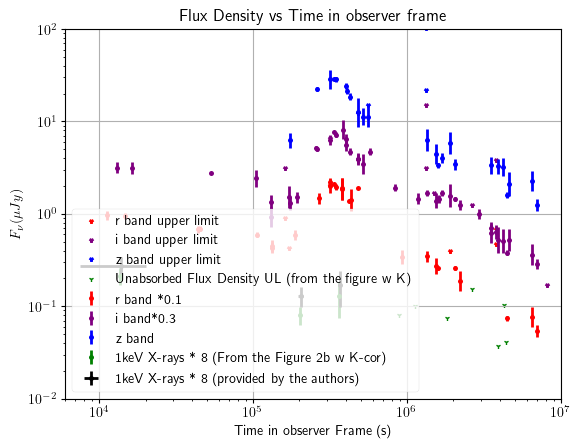

In [24]:
#IMPORTANT COMMENT: Firstly, I plot the riz optical bands and all the X-ray data obtained after the prompt emission
#to compare the EP240414a data obtained in this notebook with the one presented in Figure 3 of Zheng et al. 2025.

#Plotting the time in the observer-frame and in seconds
tor=tor.to(u.s)
toi=toi.to(u.s)
tog=tog.to(u.s)
toz=toz.to(u.s)
tormagub=tormagub.to(u.s)
toimagub=toimagub.to(u.s)
togmagub=togmagub.to(u.s)
tozmagub=tozmagub.to(u.s)
ToRadFlux=ToRadFlux.to(u.s)
ToRadFluxUB=ToRadFluxUB.to(u.s)
tobsXraySunPlot=tobsXraySunPlot*u.s
tobsXraySunPlotUB=tobsXraySunPlotUB*u.s


plt.figure()
#Firstly plotting all the optical data:
plt.errorbar(tor, fluxrMagCorr*0.1, yerr=np.vstack([fluxrMagCorr_e,fluxrMagCorr_E])*0.1, fmt='o', capsize=5, elinewidth=2, color='red', label='r band *0.1')
plt.errorbar(toi, fluxiMagCorr*0.3, yerr=np.vstack([fluxiMagCorr_e,fluxiMagCorr_E])*0.3, fmt='o', capsize=5, elinewidth=2, color='purple', label='i band*0.3')
#plt.errorbar(tog, fluxgMagCorr, yerr=np.vstack([fluxgMagCorr_e,fluxgMagCorr_E]), fmt='o', capsize=5, elinewidth=2, color='yellow', label='g band')
plt.errorbar(toz, fluxzMagCorr, yerr=np.vstack([fluxzMagCorr_e,fluxzMagCorr_E]), fmt='o', capsize=5, elinewidth=2, color='blue', label='z band')
#Upper limits:
plt.scatter(tormagub, fluxrub*0.1, color='red', marker='1', linewidth=2, label='r band upper limit') 
#plt.scatter(togmagub, fluxgub, color='yellow',marker='1', linewidth=2, label='g band upper limit')
plt.scatter(toimagub, fluxiub*0.3, color='purple', marker='1', linewidth=2, label='i band upper limit')
plt.scatter(tozmagub, fluxzub, color='blue', marker='1', linewidth=2, label='z band upper limit')

#For X-Ray
#FXT points using XSPEC:
#For the data extracted from Figure 2b) of Sun et al. 2025:
plt.errorbar(tobsXraySunPlot[1:], Fdens[1:]*8, yerr=np.vstack([Fdens_e[1:]*8, Fdens_E[1:]*8]), fmt='o', capsize=5, elinewidth=2, color='green', label='1keV X-rays * 8 (From the Figure 2b w K-cor)')
#For the flux densities derived from the unabsorbed fluxes provided by the authors:
plt.errorbar(tmeanobsall[DetSun], FluxdensSunE[DetSun]*8, yerr=np.vstack([FluxdensSunE_e[DetSun]*8, FluxdensSunE_E[DetSun]*8]), xerr=tfinall[DetSun]-tmeanobsall[DetSun], fmt='o', capsize=5, elinewidth=2, color='black', label='1keV X-rays * 8 (provided by the authors)')
#Upper limits:
#plt.scatter(tobsLumUBXray, FdensUB*8, color='r', marker='1', label='Unabsorbed Flux Density UL')
plt.scatter(tobsXraySunUB, FluxMeduJyUB*8, color='g', marker='1', label='Unabsorbed Flux Density UL (from the figure w K)')
plt.title('Flux Density vs Time in observer frame')
plt.xlabel('Time in observer Frame (s)')
plt.ylabel(rf'$F_{{\nu}} (\mu Jy)$')
plt.xscale('log')
plt.yscale('log')
plt.xlim(6e3,1e7)
plt.ylim(1e-2,1e2)
plt.legend()
plt.grid()
plt.show()

Now, plotting the corrected fluxes over all the measured frequencies for EP240414a:

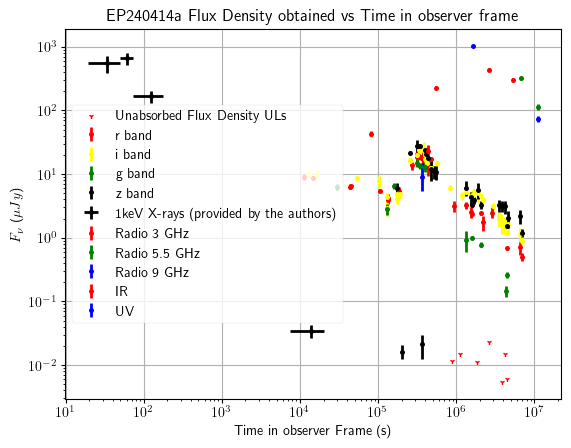

In [25]:
plt.figure()

#For the optical data:
plt.errorbar(tor, fluxr, yerr=efluxr, fmt='o', capsize=5, elinewidth=2, color='red', label='r band')
plt.errorbar(toi, fluxi, yerr=efluxi, fmt='o', capsize=5, elinewidth=2, color='yellow', label='i band')
plt.errorbar(tog, fluxg, yerr=efluxg, fmt='o', capsize=5, elinewidth=2, color='green', label='g band')
plt.errorbar(toz, fluxz, yerr=efluxz, fmt='o', capsize=5, elinewidth=2, color='black', label='z band')
#Upper limits:
#plt.scatter(tormagub, fluxrub, color='red', marker='1', linewidth=2, label='r band upper limit') 
#plt.scatter(togmagub, fluxgub, color='green',marker='1', linewidth=2, label='g band upper limit')
#plt.scatter(toimagub, fluxiub, color='yellow', marker='1', linewidth=2, label='i band upper limit')
#plt.scatter(tozmagub, fluxzub, color='black', marker='1', linewidth=2, label='z band upper limit')

#For X-Ray
plt.errorbar(tmeanobsall[DetSun], FluxdensSunE[DetSun], yerr=np.vstack([FluxdensSunE_e[DetSun], FluxdensSunE_E[DetSun]]), xerr=tfinall[DetSun]-tmeanobsall[DetSun], fmt='o', capsize=5, elinewidth=2, color='black', label='1keV X-rays (provided by the authors)')
#Upper limits:
plt.scatter(tmeanobsall[~DetSun], FluxdensSunE[~DetSun], color='r', marker='1', label='Unabsorbed Flux Density ULs')

#For radio:
plt.errorbar(ToRadFlux[0:3], RadFlux[0:3], yerr=RadFluxE[0:3], fmt='o', capsize=5, elinewidth=2, color='red', label='Radio 3 GHz')
plt.errorbar(ToRadFlux[3:5], RadFlux[3:5], yerr=RadFluxE[3:5], fmt='o', capsize=5, elinewidth=2, color='green', label='Radio 5.5 GHz')
plt.errorbar(ToRadFlux[5:7], RadFlux[5:7], yerr=RadFluxE[5:7], fmt='o', capsize=5, elinewidth=2, color='blue', label='Radio 9 GHz')
#Upper limits:
#plt.scatter(ToRadFluxUB[0], RadFluxUB[0], color='black', marker='1', linewidth=2, label='8GHz upper limits')
#plt.scatter(ToRadFluxUB[1], RadFluxUB[1], color='red', marker='1', linewidth=2, label='3GHz upper limit') 

#For IR:
plt.errorbar(tobsIR,IRFLUXCORR,yerr=np.vstack([IRFLUXCORR_e, IRFLUXCORR_E]),fmt='o', capsize=5, elinewidth=2, color='red', label='IR')
#plt.scatter(tobsIRUB, IRFLUXUBCORR, color='red', marker='1', linewidth=2, label='IR upper limit') 

#For UV:
plt.errorbar(tobsUV,UVFLUXCORR,yerr=np.vstack([UVFLUXCORR_e,UVFLUXCORR_E]),fmt='o', capsize=5, elinewidth=2, color='blue', label='UV')

plt.title('EP240414a Flux Density obtained vs Time in observer frame')
plt.xlabel('Time in observer Frame (s)')
plt.ylabel(rf'$F_{{\nu}}$ ($\mu Jy$)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.grid()
plt.show()

## Lastly, in the following code, I organise and write in .txt files the data I have extracted and corrected in the previous codes to use it in the fitting process conducted in the corresponding notebooks:

In [26]:
#For the optical data:
#Comments: Corrected for MW galactic extinction only. The data is presented in the .txt files time-ordered.
#Now, creating the arrays with all the data:
OptiLength=len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr)+len(fluxrub)+len(fluxiub)+len(fluxgub) + len(fluxzub)
ToptObserved=np.zeros(OptiLength)
ToptObservedDays=np.zeros(OptiLength)
OptFilter=[]
ULOPTICAL=[]
SourcesOPT=[]
EffectiveWavelength=np.zeros(OptiLength) #in Angstroms and assuming SDSS filters
MagOpt=np.zeros(OptiLength)
e_MagOpt=np.zeros(OptiLength)
E_MagOpt=np.zeros(OptiLength)
OptFluxes=np.zeros(OptiLength)
e_OptFluxes=np.zeros(OptiLength)
E_OptFluxes=np.zeros(OptiLength)
for i in range(0,OptiLength):
    if i<len(fluxrMagCorr):
        ToptObserved[i]=tor.value[i]
        ToptObservedDays[i]=(tor.to(u.d)).value[i]
        OptFilter.append("r")
        ULOPTICAL.append("No")
        SourcesOPT.append(sourcer[i])
        EffectiveWavelength[i]=LambEffSDSS[1]
        MagOpt[i]=rMagExC[i]
        e_MagOpt[i]=rMagExC_e[i]
        E_MagOpt[i]=rMagExC_E[i]
        OptFluxes[i]=fluxrMagCorr.value[i]
        e_OptFluxes[i]=fluxrMagCorr_e.value[i]
        E_OptFluxes[i]=fluxrMagCorr_E.value[i]
    if i>=len(fluxrMagCorr) and i<len(fluxrMagCorr)+len(fluxiMagCorr):
        ToptObserved[i]=toi.value[i-len(fluxrMagCorr)]
        ToptObservedDays[i]=(toi.to(u.d)).value[i-len(fluxrMagCorr)]
        SourcesOPT.append(sourcei[i-len(fluxrMagCorr)])
        OptFilter.append("i")
        ULOPTICAL.append("No")
        EffectiveWavelength[i]=LambEffSDSS[2]
        MagOpt[i]=iMagExC[i-len(fluxrMagCorr)]
        e_MagOpt[i]=iMagExC_e[i-len(fluxrMagCorr)]
        E_MagOpt[i]=iMagExC_E[i-len(fluxrMagCorr)]
        OptFluxes[i]=fluxiMagCorr.value[i-len(fluxrMagCorr)]
        e_OptFluxes[i]=fluxiMagCorr_e.value[i-len(fluxrMagCorr)]
        E_OptFluxes[i]=fluxiMagCorr_E.value[i-len(fluxrMagCorr)]
    if i>=len(fluxrMagCorr)+len(fluxiMagCorr) and i<len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr):
        ToptObserved[i]=tog.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
        ToptObservedDays[i]=(tog.to(u.d)).value[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
        SourcesOPT.append(sourceg[i-(len(fluxrMagCorr)+len(fluxiMagCorr))])
        OptFilter.append("g")
        ULOPTICAL.append("No")
        EffectiveWavelength[i]=LambEffSDSS[0]
        MagOpt[i]=gMagExC[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
        e_MagOpt[i]=gMagExC_e[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
        E_MagOpt[i]=gMagExC_E[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
        OptFluxes[i]=fluxgMagCorr.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
        e_OptFluxes[i]=fluxgMagCorr_e.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
        E_OptFluxes[i]=fluxgMagCorr_E.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr))]
    if i>=len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr) and i<len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr):
        ToptObserved[i]=toz.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
        ToptObservedDays[i]=(toz.to(u.d)).value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
        SourcesOPT.append(sourcez[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))])
        OptFilter.append("z")
        ULOPTICAL.append("No")
        EffectiveWavelength[i]=LambEffSDSS[3]
        MagOpt[i]=zMagExC[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
        e_MagOpt[i]=zMagExC_e[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
        E_MagOpt[i]=zMagExC_E[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
        OptFluxes[i]=fluxzMagCorr.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
        e_OptFluxes[i]=fluxzMagCorr_e.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
        E_OptFluxes[i]=fluxzMagCorr_E.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr))]
    #Now, this is for the upper limits:
    if i>=len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr) and i< OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub):
        ToptObserved[i]=tormagub.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr))]
        ToptObservedDays[i]=(tormagub.to(u.d)).value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr))]
        OptFilter.append("r-UB")
        SourcesOPT.append(sourcerUB[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr))])
        if sourcerUB[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr))]=='van Dalen et al. 2025':
            ULOPTICAL.append("Yes-1sigma")
        else:
            ULOPTICAL.append("Yes-3sigma")
        EffectiveWavelength[i]=LambEffSDSS[1]
        MagOpt[i]=rmagub[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr))]
        e_MagOpt[i]=np.nan
        E_MagOpt[i]=np.nan
        OptFluxes[i]=fluxrub.value[i-(len(fluxrMagCorr)+len(fluxiMagCorr)+len(fluxgMagCorr)+len(fluxzMagCorr))]
        e_OptFluxes[i]=np.nan
        E_OptFluxes[i]=np.nan
    if i>=OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub) and i< OptiLength-len(fluxgub)-len(fluxzub):
        ToptObserved[i]=toimagub.value[i-(OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub))]
        ToptObservedDays[i]=(toimagub.to(u.d)).value[i-(OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub))]
        SourcesOPT.append(sourceiUB[i-(OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub))])
        OptFilter.append("i-UB")
        if sourceiUB[i-(OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub))]=='van Dalen et al. 2025':
            ULOPTICAL.append("Yes-1sigma")
        else:
            ULOPTICAL.append("Yes-3sigma")
        EffectiveWavelength[i]=LambEffSDSS[2]
        MagOpt[i]=imagub[i-(OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub))]
        e_MagOpt[i]=np.nan
        E_MagOpt[i]=np.nan
        OptFluxes[i]=fluxiub.value[i-(OptiLength-len(fluxiub)-len(fluxgub)-len(fluxzub))]
        e_OptFluxes[i]=np.nan
        E_OptFluxes[i]=np.nan
    if i>=OptiLength-len(fluxgub)-len(fluxzub) and i< OptiLength-len(fluxzub):
        ToptObserved[i]=togmagub.value[i-(OptiLength-len(fluxgub)-len(fluxzub))]
        ToptObservedDays[i]=(togmagub.to(u.d)).value[i-(OptiLength-len(fluxgub)-len(fluxzub))]
        SourcesOPT.append(sourcegUB[i-(OptiLength-len(fluxgub)-len(fluxzub))])
        OptFilter.append("g-UB")
        if sourcegUB[i-(OptiLength-len(fluxgub)-len(fluxzub))]=='van Dalen et al. 2025':
            ULOPTICAL.append("Yes-1sigma")
        else:
            ULOPTICAL.append("Yes-3sigma")
        EffectiveWavelength[i]=LambEffSDSS[0]
        MagOpt[i]=gmagub[i-(OptiLength-len(fluxgub)-len(fluxzub))]
        e_MagOpt[i]=np.nan
        E_MagOpt[i]=np.nan
        OptFluxes[i]=fluxgub.value[i-(OptiLength-len(fluxgub)-len(fluxzub))]
        e_OptFluxes[i]=np.nan
        E_OptFluxes[i]=np.nan
    if i>=OptiLength-len(fluxzub) and i< OptiLength:
        ToptObserved[i]=tozmagub.value[i-(OptiLength-len(fluxzub))]
        ToptObservedDays[i]=(tozmagub.to(u.d)).value[i-(OptiLength-len(fluxzub))]
        SourcesOPT.append(sourcezUB[i-(OptiLength-len(fluxzub))])
        OptFilter.append("z-UB")
        if sourcezUB[i-(OptiLength-len(fluxzub))]=='van Dalen et al. 2025':
            ULOPTICAL.append("Yes-1sigma")
        else:
            ULOPTICAL.append("Yes-3sigma")
        EffectiveWavelength[i]=LambEffSDSS[3]
        MagOpt[i]=zmagub[i-(OptiLength-len(fluxzub))]
        e_MagOpt[i]=np.nan
        E_MagOpt[i]=np.nan
        OptFluxes[i]=fluxzub.value[i-(OptiLength-len(fluxzub))]
        e_OptFluxes[i]=np.nan
        E_OptFluxes[i]=np.nan

#To write the time-ordered data:
OpticalTimeDaysSortedIndices=np.argsort(ToptObserved)
SORTEDFILT=[OptFilter[i] for i in OpticalTimeDaysSortedIndices]
SortedFilt=[SourcesOPT[i] for i in OpticalTimeDaysSortedIndices]


OptFilter = np.asarray(OptFilter)
SourcesOPT = np.asarray(SourcesOPT)
EffectiveWavelength = np.asarray(EffectiveWavelength)
MagOpt = np.asarray(MagOpt)
e_MagOpt = np.asarray(e_MagOpt)
E_MagOpt = np.asarray(E_MagOpt)
OptFluxes = np.asarray(OptFluxes)
e_OptFluxes = np.asarray(e_OptFluxes)
E_OptFluxes = np.asarray(E_OptFluxes)
ULOPTICAL = np.asarray(ULOPTICAL)

Optdata = {
    'Since-Trigger-Observed(s)': pd.Series(ToptObserved[OpticalTimeDaysSortedIndices]),
    'Since-Trigger-Observed(d)': pd.Series(ToptObservedDays[OpticalTimeDaysSortedIndices]),
    'Filter': pd.Series(OptFilter[OpticalTimeDaysSortedIndices]),
    'Effective-Wavelength(Angstroms)': pd.Series(EffectiveWavelength[OpticalTimeDaysSortedIndices]),
    'AB-Magnitude': pd.Series(MagOpt[OpticalTimeDaysSortedIndices]),
    'AB-Magnitude_e': pd.Series(e_MagOpt[OpticalTimeDaysSortedIndices]),
    'AB-Magnitude_E': pd.Series(E_MagOpt[OpticalTimeDaysSortedIndices]),
    'Flux-Density(micro-Jankys)': pd.Series(OptFluxes[OpticalTimeDaysSortedIndices]),
    'Flux-Density_e(micro-Jankys)':pd.Series(e_OptFluxes[OpticalTimeDaysSortedIndices]),
    'Flux-Density_E(micro-Jankys)':pd.Series(E_OptFluxes[OpticalTimeDaysSortedIndices]),
    'Upper Limits Nature': pd.Series(ULOPTICAL[OpticalTimeDaysSortedIndices]),
    'Source': pd.Series(SourcesOPT[OpticalTimeDaysSortedIndices])
}
OptDataShort = pd.DataFrame(Optdata)
OptDataShort.to_csv('EP240414a Edu processed data/All Optical Data EP240414a.txt', sep='\t', index=False, na_rep='')

For the UV and IR data:

In [27]:
#Comment: Corrected for MW extinction only and time-ordered.

IRUVLength=len(IRFLUXCORR.data)+len(UVFLUXCORR.data)+len(IRFLUXUBCORR.data)
TIRUVObserved=np.zeros(IRUVLength)
TIRUVObservedDays=np.zeros(IRUVLength)
IRUVFilter=[]
ULIRUV=[]
SourcesIRUV=[]
EffWaveIRUV=np.zeros(IRUVLength) #In Angstroms
MagIRUV=np.zeros(IRUVLength)
e_MagIRUV=np.zeros(IRUVLength)
E_MagIRUV=np.zeros(IRUVLength)
IRUVFluxes=np.zeros(IRUVLength)
e_IRUVFluxes=np.zeros(IRUVLength)
E_IRUVFluxes=np.zeros(IRUVLength)


for i in range(0,IRUVLength):
    if i<len(IRFLUXCORR.data):
        TIRUVObserved[i]=tobsIR.value[i]
        TIRUVObservedDays[i]=(tobsIR.to(u.d)).value[i]
        IRUVFilter.append(Filter[i])
        SourcesIRUV.append(sourceIR[i])
        ULIRUV.append("No")
        EffWaveIRUV[i]=LambEffIRUV[i]
        MagIRUV[i]=IRmagCorr[i]
        e_MagIRUV[i]=IRmagCorr_e[i]
        E_MagIRUV[i]=IRmagCorr_E[i]
        IRUVFluxes[i]=IRFLUXCORR.value[i]
        e_IRUVFluxes[i]=IRFLUXCORR_e.value[i]
        E_IRUVFluxes[i]=IRFLUXCORR_E.value[i]
    if i>=len(IRFLUXCORR.data) and i<len(IRFLUXCORR.data)+len(UVFLUXCORR.data):
        TIRUVObserved[i]=tobsUV.value
        TIRUVObservedDays[i]=(tobsUV.to(u.d)).value
        IRUVFilter.append(FilterUV[0])
        SourcesIRUV.append(sourceUV[0])
        ULIRUV.append("No")
        EffWaveIRUV[i]=LambEffIRUV[-1]
        MagIRUV[i]=UVmagCorr
        e_MagIRUV[i]=UVmagCorr_e
        E_MagIRUV[i]=UVmagCorr_E
        IRUVFluxes[i]=UVFLUXCORR.value
        e_IRUVFluxes[i]=UVFLUXCORR_e.value
        E_IRUVFluxes[i]=UVFLUXCORR_E.value
    if i>=len(IRFLUXCORR.data)+len(UVFLUXCORR.data) and i<IRUVLength:
        TIRUVObserved[i]=tobsIRUB.value[i-(len(IRFLUXCORR.data)+len(UVFLUXCORR.data))]
        TIRUVObservedDays[i]=(tobsIRUB.to(u.d)).value[i-(len(IRFLUXCORR.data)+len(UVFLUXCORR.data))]
        IRUVFilter.append(FilterUB[i-(len(IRFLUXCORR.data)+len(UVFLUXCORR.data))])
        SourcesIRUV.append(sourceIRUB[i-(len(IRFLUXCORR.data)+len(UVFLUXCORR.data))])
        if i-(len(IRFLUXCORR.data)+len(UVFLUXCORR.data)) == 1:
            ULIRUV.append("Yes-3sigma")
        else:
            ULIRUV.append("Yes-1sigma")
        EffWaveIRUV[i]=LambEffIRUV[i-1]
        MagIRUV[i]=IRmagUBCorr[i-(len(IRFLUXCORR.data)+len(UVFLUXCORR.data))]
        e_MagIRUV[i]=np.nan
        E_MagIRUV[i]=np.nan
        IRUVFluxes[i]=IRFLUXUBCORR.value[i-(len(IRFLUXCORR.data)+len(UVFLUXCORR.data))]
        e_IRUVFluxes[i]=np.nan
        E_IRUVFluxes[i]=np.nan

IRUVTimeDaysSortedIndices=np.argsort(TIRUVObserved)

IRUVFilter = np.asarray(IRUVFilter)
SourcesIRUV = np.asarray(SourcesIRUV)
EffWaveIRUV = np.asarray(EffWaveIRUV)
ULIRUV = np.asarray(ULIRUV)

IRUVData = {
    'Since-Trigger-Observed (s)': pd.Series(TIRUVObserved[IRUVTimeDaysSortedIndices]),
    'Since-Trigger-Observed (d)': pd.Series(TIRUVObservedDays[IRUVTimeDaysSortedIndices]),
    'Filter': pd.Series(IRUVFilter[IRUVTimeDaysSortedIndices]),
    'Effective-Wavelength(Angstroms)': pd.Series(EffWaveIRUV[IRUVTimeDaysSortedIndices]),
    'AB-Magnitude': pd.Series(MagIRUV[IRUVTimeDaysSortedIndices]),
    'AB-Magnitude_e': pd.Series(e_MagIRUV[IRUVTimeDaysSortedIndices]),
    'AB-Magnitude_E': pd.Series(E_MagIRUV[IRUVTimeDaysSortedIndices]),
    'Flux-Density(micro-Jankys)': pd.Series(IRUVFluxes[IRUVTimeDaysSortedIndices]),
    'Flux-Density_e(micro-Jankys)':pd.Series(e_IRUVFluxes[IRUVTimeDaysSortedIndices]),
    'Flux-Density_E(micro-Jankys)':pd.Series(E_IRUVFluxes[IRUVTimeDaysSortedIndices]),
    'Upper Limits Nature': pd.Series(ULIRUV[IRUVTimeDaysSortedIndices]),
    'Source': pd.Series(SourcesIRUV[IRUVTimeDaysSortedIndices])
}
IRUVDataShort = pd.DataFrame(IRUVData)
IRUVDataShort.to_csv('EP240414a Edu processed data/All IR UV Data EP240414a.txt', sep='\t', index=False, na_rep='')

For the radio data:

In [28]:
Radiolength=len(RadFlux.data)+len(RadFluxUB.data)
ULRADIO=[]
TRadObserved=np.zeros(Radiolength)
RadFreq=np.zeros(Radiolength)
RadFluxes=np.zeros(Radiolength)
e_RadFluxes=np.zeros(Radiolength) 

for i in range(0,Radiolength):
    if i<3:
        TRadObserved[i]=ToRadFlux.value[i]
        RadFreq[i]=3
        RadFluxes[i]=RadFlux.value[i]
        e_RadFluxes[i]=RadFluxE.value[i]
        ULRADIO.append('No')
    if i>=3 and i<6:
        TRadObserved[i]=ToRadFlux.value[i]
        RadFreq[i]=5.5
        RadFluxes[i]=RadFlux.value[i]
        e_RadFluxes[i]=RadFluxE.value[i]
        ULRADIO.append('No')
    if i>=6 and i<len(RadFlux.data):
        TRadObserved[i]=ToRadFlux.value[i]
        RadFreq[i]=9
        RadFluxes[i]=RadFlux.value[i]
        e_RadFluxes[i]=RadFluxE.value[i]
        ULRADIO.append('No')
    if i>=len(RadFlux.data) and i<Radiolength-1:
        TRadObserved[i]=ToRadFluxUB.value[i-len(RadFlux.data)]
        RadFreq[i]=8
        RadFluxes[i]=RadFluxUB.value[i-len(RadFlux.data)]
        e_RadFluxes[i]=np.nan
        ULRADIO.append('Yes-3sigma')
    if i==Radiolength-1:
        TRadObserved[i]=ToRadFluxUB.value[i-Radiolength]
        RadFreq[i]=3
        RadFluxes[i]=RadFluxUB.value[i-Radiolength]
        e_RadFluxes[i]=np.nan
        ULRADIO.append('Yes-3sigma')
TRadObservedDays=((TRadObserved*u.s).to(u.d)).value
RadioTimeDaysSortedIndices=np.argsort(TRadObserved)

RadFreq = np.asarray(RadFreq)
SourceRad = np.asarray(SourceRad)
ULRADIO = np.asarray(ULRADIO)

RadData = {
    'Since-Trigger-Observed(s)': pd.Series(TRadObserved[RadioTimeDaysSortedIndices]),
    'Since-Trigger-Observed(d)': pd.Series(TRadObservedDays[RadioTimeDaysSortedIndices]),
    'Frequency(GHz)': pd.Series(RadFreq[RadioTimeDaysSortedIndices]),
    'Flux-Density-(micro-Jankys)': pd.Series(RadFluxes[RadioTimeDaysSortedIndices]),
    'Flux-Density-error-(micro-Jankys)':pd.Series(e_RadFluxes[RadioTimeDaysSortedIndices]),
    'Upper Limit Nature' : pd.Series(ULRADIO[RadioTimeDaysSortedIndices]),
    'Source of Data' : pd.Series(SourceRad[RadioTimeDaysSortedIndices])
}
RadDataShort = pd.DataFrame(RadData)
RadDataShort.to_csv('EP240414a Edu processed data/All Radio Data EP240414a.txt', sep='\t', index=False, na_rep='')

And for the X-ray data (obtained from the unabsorbed fluxes provided by the authors):

In [29]:
XrayLength=len(UnabsFluxSunAll)
FrequencyEval=np.ones(XrayLength)
tstalldays=((tstall).to(u.d)).value
tfinalldays=((tfinall).to(u.d)).value
tmeanobsalldays=((tmeanobsall).to(u.d)).value
XraysTimeDaysSortedIndices=np.argsort(tmeanobsalldays)

SunInstrument = np.asarray(SunInstrument)
SunUL = np.asarray(SunUL)

XrayData = {
    'Instrument': pd.Series(SunInstrument[XraysTimeDaysSortedIndices]),
    'Frequency-of-evaluation-of-Fnu(KeV)': pd.Series(FrequencyEval[XraysTimeDaysSortedIndices]),
    'Since-Trigger-Observed(s)': pd.Series(tmeanobsall[XraysTimeDaysSortedIndices]),
    'Start-Observation-Time(s)': pd.Series(tstall[XraysTimeDaysSortedIndices]),
    'Final-Observation-Time(s)': pd.Series(tfinall[XraysTimeDaysSortedIndices]),
    'Since-Trigger-Observed(d)': pd.Series(tmeanobsalldays[XraysTimeDaysSortedIndices]),
    'Start-Observation-Time(d)': pd.Series(tstalldays[XraysTimeDaysSortedIndices]),
    'Final-Observation-Time(d)': pd.Series(tfinalldays[XraysTimeDaysSortedIndices]),
    'Flux-Density(micro-Jankys)': pd.Series(FluxdensSunE[XraysTimeDaysSortedIndices]),
    'Flux-Density_e(micro-Jankys)':pd.Series(FluxdensSunE_e[XraysTimeDaysSortedIndices]),
    'Flux-Density_E(micro-Jankys)':pd.Series(FluxdensSunE_E[XraysTimeDaysSortedIndices]),
    'Upper Limit Nature' : pd.Series(SunUL[XraysTimeDaysSortedIndices]),
}
XrayDataShort = pd.DataFrame(XrayData)
XrayDataShort.to_csv('EP240414a Edu processed data/Xray Data EP240414a.txt', sep='\t', index=False, na_rep='')